# Compare Trained Go/No-Go Networks

This notebook loads the trained low-rank RNN, full-rank RNN, and LSTM from `homework_CN/outputs`, tests them on the same 3-context Go/No-Go task, and compares:

- training curves and final performance
- final scalar outputs for every context/stimulus rule
- output trajectories across the 10 timestep trial
- hidden-state PCA trajectories as a first look at latent dynamics

Test design: 3 repeated trials for each of the 6 task cases: `3 contexts x 2 stimuli x 3 repeats = 18 trials`.

## 1. Setup

The notebook is written to run either from the project root or from inside `homework_CN`.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
import sys
import importlib
import shutil

HOMEWORK_DIR = Path("/content/drive/MyDrive/homework_CN").resolve()
OUTPUT_DIR = HOMEWORK_DIR / "outputs"

# Vérification basique
assert HOMEWORK_DIR.exists(), f"Le dossier n'existe pas : {HOMEWORK_DIR}"
assert (HOMEWORK_DIR / "lstm_rnn.py").exists(), "lstm_rnn.py est introuvable"

# Supprime les anciens chemins identiques ou proches
sys.path = [
    p for p in sys.path
    if str(HOMEWORK_DIR) not in str(p)
]

# Réinsère proprement le dossier en première position
sys.path.insert(0, str(HOMEWORK_DIR))

# Supprime les modules éventuellement chargés/cassés
for module_name in [
    "low_rank_rnn",
    "full_rank_rnn",
    "lstm_rnn",
    "train_context_gonogo",
]:
    sys.modules.pop(module_name, None)

# Supprime le cache Python compilé
pycache = HOMEWORK_DIR / "__pycache__"
if pycache.exists():
    shutil.rmtree(pycache)

# Force Python à oublier ses caches d'import
importlib.invalidate_caches()

print("sys.path[0] =", sys.path[0])
print("lstm_rnn.py exists:", (HOMEWORK_DIR / "lstm_rnn.py").exists())
print("lstm_rnn.py size:", (HOMEWORK_DIR / "lstm_rnn.py").stat().st_size)

print("find_spec('lstm_rnn') =", importlib.util.find_spec("lstm_rnn"))

sys.path[0] = /content/drive/.shortcut-targets-by-id/1A4IkgdtY5v7Nx1dsR5SS37_MVJcIRmd5/homework_CN
lstm_rnn.py exists: True
lstm_rnn.py size: 1373
find_spec('lstm_rnn') = ModuleSpec(name='lstm_rnn', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7b4b767ca210>, origin='/content/drive/.shortcut-targets-by-id/1A4IkgdtY5v7Nx1dsR5SS37_MVJcIRmd5/homework_CN/lstm_rnn.py')


In [ ]:
from low_rank_rnn import LowRankRNN
from full_rank_rnn import FullRankRNN
from lstm_rnn import LSTMRNN
from train_context_gonogo import ContextGoNoGoTask

import torch as T
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from types import SimpleNamespace
import torch.nn.functional as F

DEVICE = T.device("cuda" if T.cuda.is_available() else "cpu")

print("HOMEWORK_DIR:", HOMEWORK_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("DEVICE:", DEVICE)

HOMEWORK_DIR: /content/drive/.shortcut-targets-by-id/1A4IkgdtY5v7Nx1dsR5SS37_MVJcIRmd5/homework_CN
OUTPUT_DIR: /content/drive/.shortcut-targets-by-id/1A4IkgdtY5v7Nx1dsR5SS37_MVJcIRmd5/homework_CN/outputs
DEVICE: cpu


In [ ]:
# @title
from pathlib import Path
import sys
import json
from types import SimpleNamespace

import numpy as np
import pandas as pd
import torch as T
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Set the HOMEWORK_DIR directly to the Google Drive path where the modules are located.
HOMEWORK_DIR = Path("/content/drive/MyDrive/homework_CN")

OUTPUT_DIR = HOMEWORK_DIR / "outputs"
sys.path.insert(0, str(HOMEWORK_DIR))

# Diagnostic check for missing module files
required_modules = ["low_rank_rnn", "full_rank_rnn", "lstm_rnn", "train_context_gonogo"]
missing_files = []
for module_name in required_modules:
    module_path = HOMEWORK_DIR / f"{module_name}.py"
    if not module_path.exists():
        missing_files.append(f"{module_name}.py")

if missing_files:
    print(f"Error: The following module files are missing from {HOMEWORK_DIR}: {', '.join(missing_files)}")
    print("Please ensure these files are present in the HOMEWORK_DIR. This often requires cloning a repository.")

from low_rank_rnn import LowRankRNN
from full_rank_rnn import FullRankRNN
from lstm_rnn import LSTMRNN
from train_context_gonogo import ContextGoNoGoTask

DEVICE = T.device("cuda" if T.cuda.is_available() else "cpu")
print("HOMEWORK_DIR:", HOMEWORK_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("DEVICE:", DEVICE)

HOMEWORK_DIR: /content/drive/MyDrive/homework_CN
OUTPUT_DIR: /content/drive/MyDrive/homework_CN/outputs
DEVICE: cpu


## 2. Load Trained Networks

The loader reads the checkpoint metadata and reconstructs each architecture with the same `hidden_size`, `rank`, `seq_len`, and `alpha` used during training.

In [ ]:
MODEL_FILES = {
    "low_rank": OUTPUT_DIR / "low_rank_final_model.pt",
    "full_rank": OUTPUT_DIR / "full_rank_final_model.pt",
    "lstm": OUTPUT_DIR / "lstm_final_model.pt",
}


def build_model(model_type, args):
    common = dict(input_size=5, hidden_size=args.hidden_size, output_size=1)
    if model_type == "low_rank":
        return LowRankRNN(rank=args.rank, alpha=args.alpha, **common)
    if model_type == "full_rank":
        return FullRankRNN(alpha=args.alpha, **common)
    if model_type == "lstm":
        return LSTMRNN(**common)
    raise ValueError(f"Unknown model type: {model_type}")


def load_trained_model(path):
    ckpt = T.load(path, map_location=DEVICE)
    args = SimpleNamespace(**ckpt["args"])
    model_type = ckpt["model_type"]
    model = build_model(model_type, args).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    return model, args, ckpt

models = {}
model_args = {}
checkpoints = {}
for name, path in MODEL_FILES.items():
    model, args, ckpt = load_trained_model(path)
    models[name] = model
    model_args[name] = args
    checkpoints[name] = ckpt
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{name:9s} | hidden={args.hidden_size} rank={args.rank} seq_len={args.seq_len} alpha={args.alpha} trainable={n_trainable:,}")

low_rank  | hidden=256 rank=1 seq_len=10 alpha=0.2 trainable=2,048
full_rank | hidden=256 rank=1 seq_len=10 alpha=0.2 trainable=67,072
lstm      | hidden=256 rank=1 seq_len=10 alpha=0.2 trainable=269,569


## 3. Compare Training Curves

These curves come from the saved `*_metrics.json` files created during training.

In [ ]:
# @title
def load_metrics(name):
    with (OUTPUT_DIR / f"{name}_metrics.json").open() as f:
        return json.load(f)

metrics = {name: load_metrics(name) for name in models}
summary_rows = []
for name, data in metrics.items():
    args = model_args[name]
    summary_rows.append({
        "model": name,
        "steps": args.steps,
        "hidden_size": args.hidden_size,
        "rank": args.rank if name == "low_rank" else None,
        "repeats_per_case": args.repeats_per_case,
        "final_accuracy": data["final_accuracy"],
        "final_mse": data["final_mse"],
    })
summary_df = pd.DataFrame(summary_rows)
summary_df

,model,steps,hidden_size,rank,repeats_per_case,final_accuracy,final_mse
0,low_rank,10000,256,1.0,4,1.0,6.347515e-13
1,full_rank,5000,256,NaN,4,1.0,4.249175e-07
2,lstm,5000,256,NaN,4,1.0,6.766134e-10


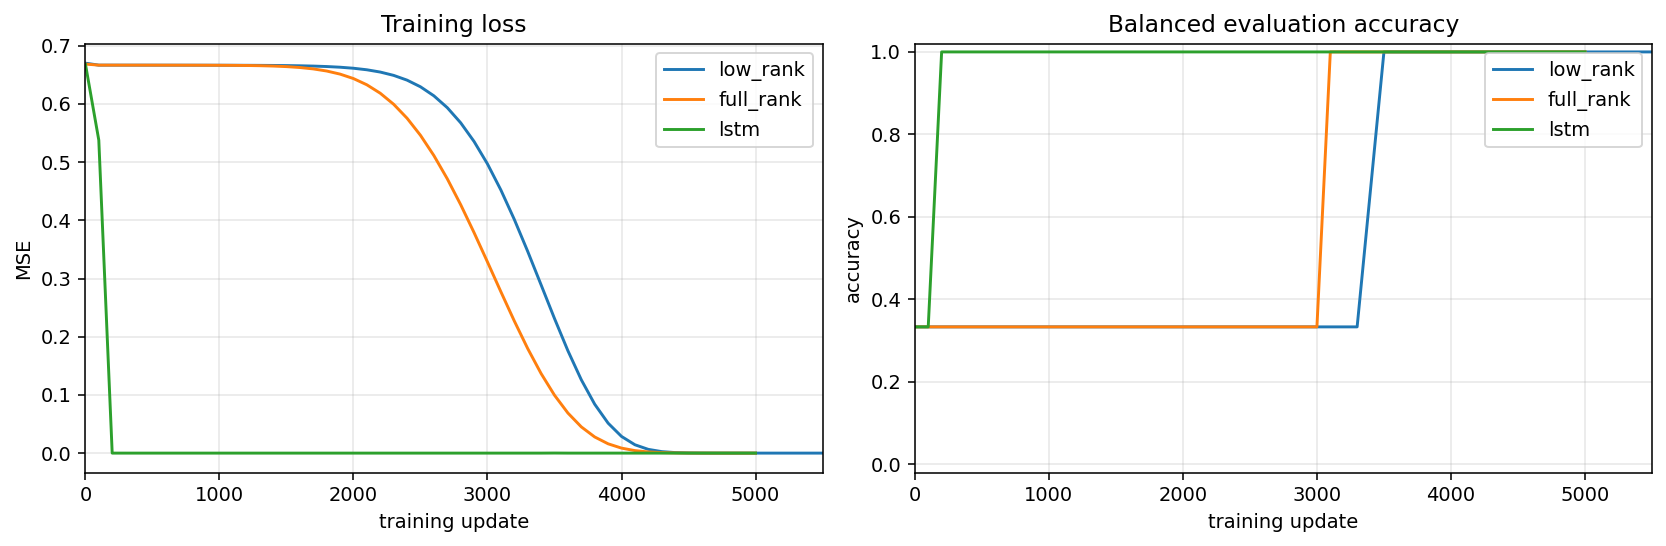

In [ ]:
# @title
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=140)

for name, data in metrics.items():
    hist = data["history"]
    axes[0].plot(hist["step"], hist["loss"], label=name)
    axes[1].plot(hist["step"], hist["accuracy"], label=name)

axes[0].set_title("Training loss")
axes[0].set_xlabel("training update")
axes[0].set_ylabel("MSE")
axes[0].set_xlim(0, 5500)
axes[0].set_yscale("linear")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_title("Balanced evaluation accuracy")
axes[1].set_xlabel("training update")
axes[1].set_ylabel("accuracy")
axes[1].set_ylim(-0.02, 1.02)
axes[1].set_xlim(0, 5500)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Build a Small Test Set

We test 3 repeated trials per context/stimulus pair. Because the task and networks are deterministic, repeated trials should produce identical outputs; keeping repeats makes the test design explicit and easy to explain.

In [ ]:
task = ContextGoNoGoTask(seq_len=model_args["low_rank"].seq_len)
TEST_REPEATS_PER_CASE = 3
inputs, targets, contexts, stimuli = task.make_balanced_batch(TEST_REPEATS_PER_CASE, DEVICE)

case_df = pd.DataFrame({
    "trial": np.arange(len(contexts.cpu())),
    "context": contexts.cpu().numpy(),
    "stimulus": stimuli.cpu().numpy().astype(int),
    "target": targets.squeeze(1).cpu().numpy().astype(int),
})
case_df.head(18)

,trial,context,stimulus,target
0,0,0,-1,0
1,1,0,-1,0
2,2,0,-1,0
3,3,0,1,0
4,4,0,1,0
5,5,0,1,0
6,6,1,-1,-1
7,7,1,-1,-1
8,8,1,-1,-1
9,9,1,1,1


## 5. Output and Performance on the Test Set

The networks produce a scalar output. For behavioral accuracy, scalar outputs are discretized into `-1`, `0`, `+1` using thresholds at `-1/3` and `+1/3`.

In [ ]:
@T.no_grad()
def run_test_set(model):
    outputs, states = model(inputs, return_states=True)
    final_output = outputs[:, -1, :]
    pred = task.discretize(final_output)
    acc = (task.value_to_index(pred) == task.value_to_index(targets)).float().mean().item()
    mse = F.mse_loss(final_output, targets).item()
    return outputs.cpu(), states.cpu(), final_output.cpu(), pred.cpu(), acc, mse

results = {}
for name, model in models.items():
    outputs, states, final_output, pred, acc, mse = run_test_set(model)
    results[name] = {
        "outputs": outputs,
        "states": states,
        "final_output": final_output,
        "prediction": pred,
        "accuracy": acc,
        "mse": mse,
    }
    print(f"{name:9s} | test accuracy={acc:.3f} | test MSE={mse:.3e}")

low_rank  | test accuracy=1.000 | test MSE=6.490e-13
full_rank | test accuracy=1.000 | test MSE=4.250e-07
lstm      | test accuracy=1.000 | test MSE=2.195e-09


In [ ]:
rows = []
for name, res in results.items():
    for i in range(len(case_df)):
        rows.append({
            "model": name,
            "trial": i,
            "context": int(contexts[i].cpu()),
            "stimulus": int(stimuli[i].cpu()),
            "target": int(targets[i].item()),
            "raw_output": float(res["final_output"][i].item()),
            "prediction": int(res["prediction"][i].item()),
        })
output_df = pd.DataFrame(rows)
output_df.head(18)

,model,trial,context,stimulus,target,raw_output,prediction
0,low_rank,0,0,-1,0,1.430511e-06,0
1,low_rank,1,0,-1,0,1.430511e-06,0
2,low_rank,2,0,-1,0,1.430511e-06,0
3,low_rank,3,0,1,0,6.556511e-07,0
4,low_rank,4,0,1,0,6.556511e-07,0
5,low_rank,5,0,1,0,6.556511e-07,0
6,low_rank,6,1,-1,-1,-9.999992e-01,-1
7,low_rank,7,1,-1,-1,-9.999992e-01,-1
8,low_rank,8,1,-1,-1,-9.999992e-01,-1
9,low_rank,9,1,1,1,9.999998e-01,1


In [ ]:
# Average repeated trials for a compact 6-case comparison.
case_mean = (
    output_df
    .groupby(["model", "context", "stimulus", "target"], as_index=False)
    .agg(raw_output=("raw_output", "mean"), prediction=("prediction", "first"))
)
case_mean

,model,context,stimulus,target,raw_output,prediction
0,full_rank,0,-1,0,-2.069473e-04,0
1,full_rank,0,1,0,2.537966e-04,0
2,full_rank,1,-1,-1,-9.990605e-01,-1
3,full_rank,1,1,1,9.990816e-01,1
4,full_rank,2,-1,1,9.994161e-01,1
5,full_rank,2,1,-1,-9.993872e-01,-1
6,low_rank,0,-1,0,1.430511e-06,0
7,low_rank,0,1,0,6.556511e-07,0
8,low_rank,1,-1,-1,-9.999992e-01,-1
9,low_rank,1,1,1,9.999998e-01,1


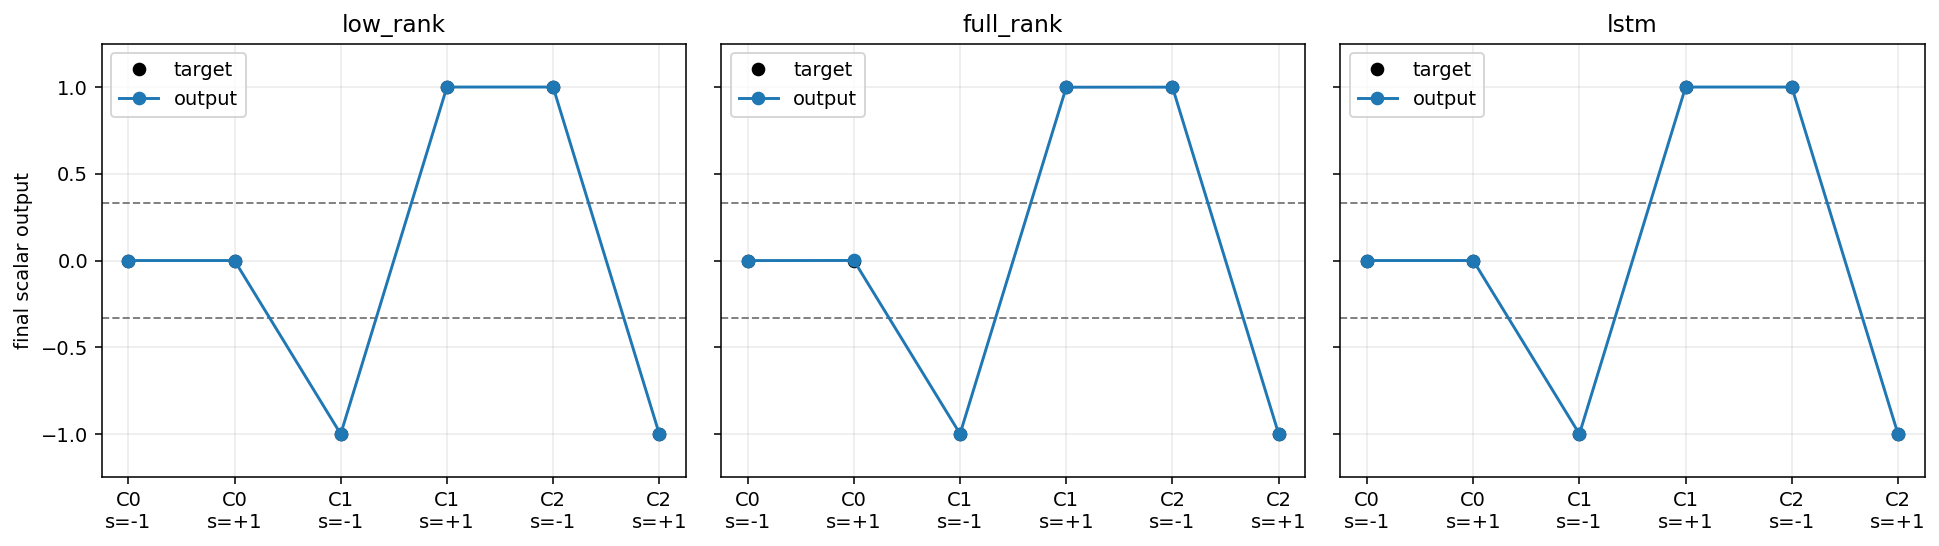

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True, dpi=140)
case_order = [(c, s) for c in range(3) for s in (-1, 1)]
x = np.arange(len(case_order))
labels = [f"C{c}\ns={s:+d}" for c, s in case_order]

target_values = []
for c, s in case_order:
    target_values.append(case_mean[(case_mean.context == c) & (case_mean.stimulus == s)].target.iloc[0])

for ax, name in zip(axes, models.keys()):
    sub = case_mean[case_mean.model == name]
    y = []
    for c, s in case_order:
        y.append(sub[(sub.context == c) & (sub.stimulus == s)].raw_output.iloc[0])
    ax.axhline(1/3, color="grey", ls="--", lw=1)
    ax.axhline(-1/3, color="grey", ls="--", lw=1)
    ax.plot(x, target_values, "ko", label="target")
    ax.plot(x, y, "o-", label="output")
    ax.set_title(name)
    ax.set_xticks(x, labels)
    ax.set_ylim(-1.25, 1.25)
    ax.grid(True, alpha=0.25)
    ax.legend()

axes[0].set_ylabel("final scalar output")
plt.tight_layout()
plt.show()

## 6. Output Trajectories Across the Trial

These plots show the scalar readout at every timestep. The final timestep is the behavioral decision point because that is when the go cue is present.

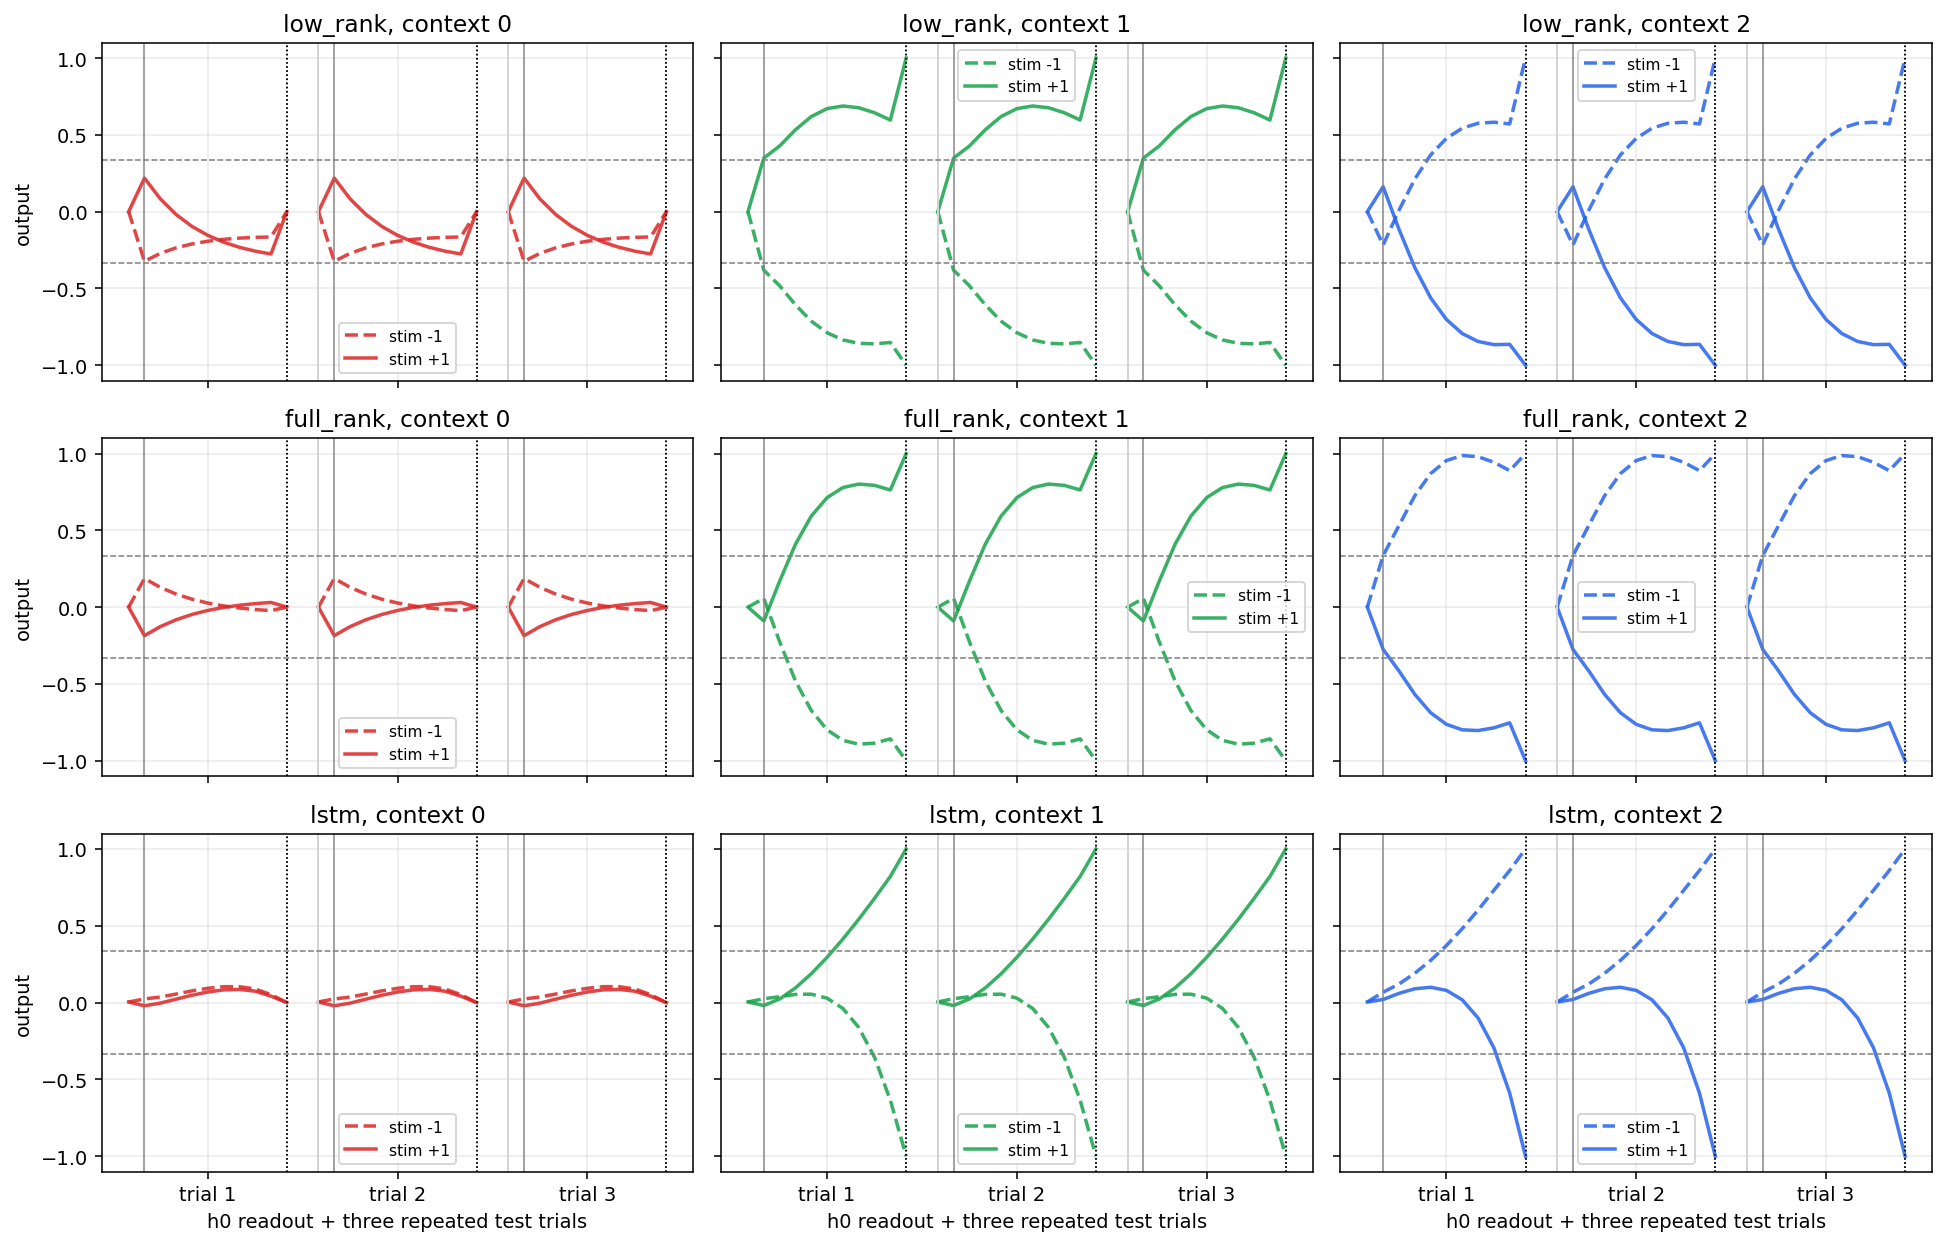

In [ ]:
colors = {0: "#dc2626", 1: "#16a34a", 2: "#2563eb"}
linestyles = {-1: "--", 1: "-"}

def initial_readout(model, model_name):
    """Readout from the default initial state h0 before any input."""
    with T.no_grad():
        if model_name == "lstm":
            # For LSTM, default hidden/cell states are zeros.
            h0 = T.zeros(1, 1, model.hidden_size, device=DEVICE)
            y0 = model.readout(h0.squeeze(0))
            return float(y0.squeeze().cpu())

        # For low-rank and full-rank RNNs, read out tanh(h0).
        h0 = model.h0.to(DEVICE)
        rates = T.tanh(h0)
        y0 = rates @ model.W_out.t()
        return float(y0.squeeze().cpu())


trial_len = task.seq_len
gap = 1

# Add one pre-trial timestep at x=-1 for h0 readout.
pre_len = 1
plot_trial_len = trial_len + pre_len
trial_stride = plot_trial_len + gap

trial_x = np.arange(-1, trial_len)
real_trial_x = np.arange(trial_len)
trial_centers = [
    (trial_x.mean() + k * trial_stride)
    for k in range(TEST_REPEATS_PER_CASE)
]

fig, axes = plt.subplots(3, 3, figsize=(14, 9), sharex=True, sharey=True, dpi=140)

for row, (name, res) in enumerate(results.items()):
    outputs = res["outputs"].squeeze(-1).numpy()
    y0 = initial_readout(models[name], name)

    for context_id in range(3):
        ax = axes[row, context_id]

        for stimulus in (-1, 1):
            mask = (
                (contexts.cpu().numpy() == context_id)
                & (stimuli.cpu().numpy() == stimulus)
            )

            trial_indices = np.where(mask)[0][:TEST_REPEATS_PER_CASE]

            for repeat_i, trial_idx in enumerate(trial_indices):
                x = trial_x + repeat_i * trial_stride

                # Prepend h0 readout at t=-1.
                y = np.concatenate([[y0], outputs[trial_idx]])

                label = f"stim {stimulus:+d}" if repeat_i == 0 else None

                ax.plot(
                    x,
                    y,
                    color=colors[context_id],
                    ls=linestyles[stimulus],
                    lw=1.8,
                    alpha=0.85,
                    label=label,
                )

                # Mark stimulus onset t=0.
                ax.axvline(
                    0 + repeat_i * trial_stride,
                    color="grey",
                    ls="-",
                    lw=0.8,
                    alpha=0.6,
                )

                # Mark go cue / decision timestep.
                ax.axvline(
                    task.go_cue_t + repeat_i * trial_stride,
                    color="black",
                    ls=":",
                    lw=0.8,
                )

        for repeat_i in range(1, TEST_REPEATS_PER_CASE):
            ax.axvline(
                repeat_i * trial_stride - gap,
                color="lightgrey",
                lw=1.0,
            )

        ax.axhline(1 / 3, color="grey", ls="--", lw=0.8)
        ax.axhline(-1 / 3, color="grey", ls="--", lw=0.8)

        ax.set_title(f"{name}, context {context_id}")
        ax.set_xticks(
            trial_centers,
            [f"trial {i + 1}" for i in range(TEST_REPEATS_PER_CASE)],
        )

        ax.grid(True, alpha=0.25)

        if row == 2:
            ax.set_xlabel("h0 readout + three repeated test trials")
        if context_id == 0:
            ax.set_ylabel("output")

        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## 7. Latent Dynamics: PCA of Hidden States

This is a first mechanistic inspection. For each trained network, hidden states from all 18 test trials and all 10 timesteps are projected onto the top two principal components. Each line is the mean trajectory for one context/stimulus condition.

In [ ]:
print(inputs.shape)
print(outputs.shape)
print(states.shape)

torch.Size([18, 10, 5])
(18, 10)
torch.Size([18, 10, 256])


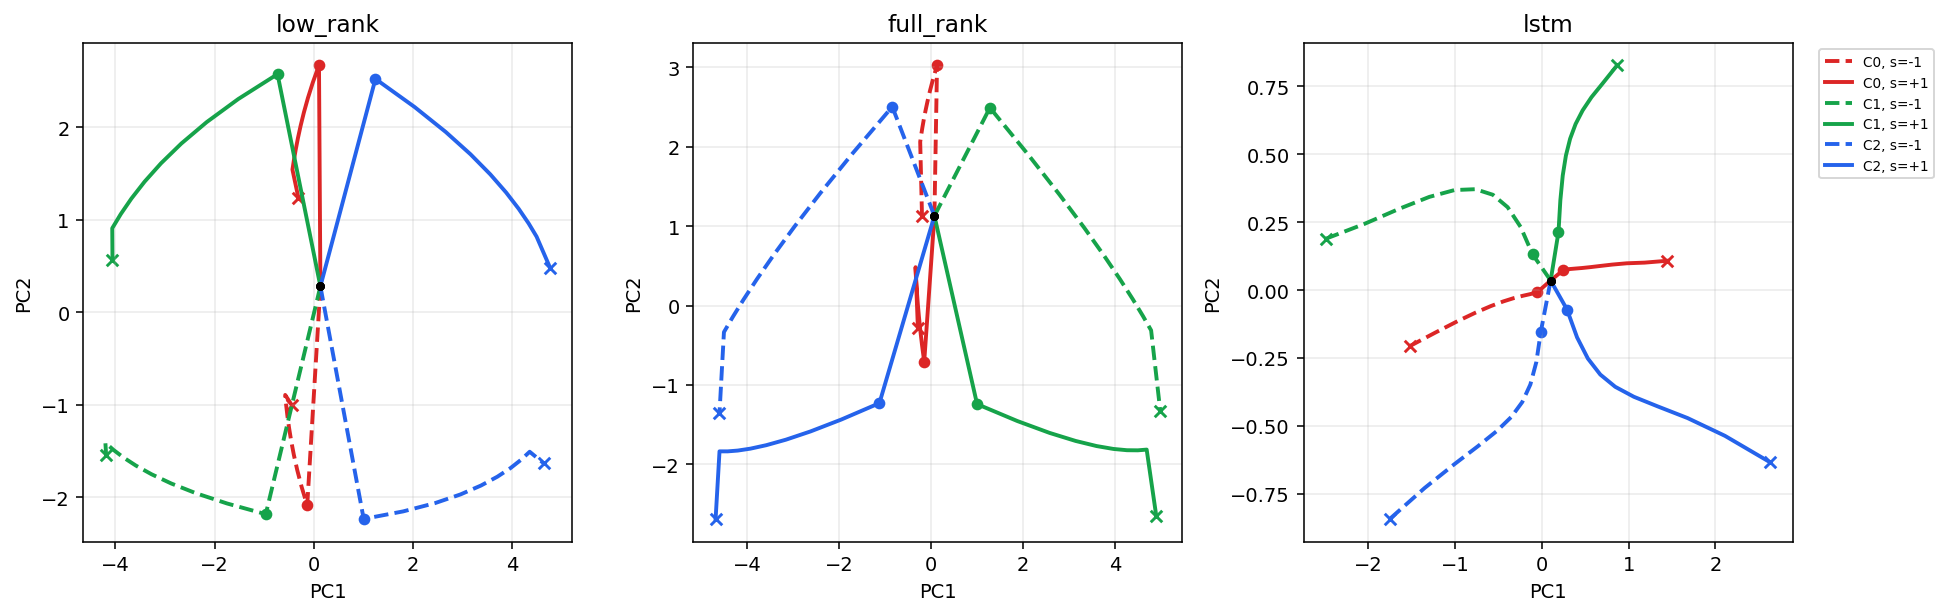

In [ ]:
def get_initial_state_for_pca(model, model_name):
    """Return initial hidden state with shape [1, hidden]."""
    with T.no_grad():
        if model_name == "lstm":
            # LSTM starts from zero hidden state by default.
            return T.zeros(1, model.hidden_size).cpu()

        # Low-rank and full-rank RNNs use model.h0.
        return model.h0.detach().cpu()


def pca_project_with_h0(states, h0):
    """
    states: [batch, time, hidden]
    h0:     [1, hidden]

    PCA is fit on both h0 and all trajectory states, then h0 is returned
    in the same PC space as the trajectories.
    """
    X_states = states.reshape(-1, states.shape[-1]).numpy()
    X_h0 = h0.numpy()

    X_all = np.concatenate([X_h0, X_states], axis=0)
    X_mean = X_all.mean(axis=0, keepdims=True)
    X_centered = X_all - X_mean

    _, _, vt = np.linalg.svd(X_centered, full_matrices=False)
    pcs = vt[:2].T

    Z_all = X_centered @ pcs
    Z_h0 = Z_all[0]
    Z_states = Z_all[1:].reshape(states.shape[0], states.shape[1], 2)

    return Z_states, Z_h0


fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), dpi=140)

for ax, (name, res) in zip(axes, results.items()):
    h0 = get_initial_state_for_pca(models[name], name)
    Z, Z_h0 = pca_project_with_h0(res["states"], h0)

    for context_id in range(3):
        for stimulus in (-1, 1):
            mask = (
                (contexts.cpu().numpy() == context_id)
                & (stimuli.cpu().numpy() == stimulus)
            )

            # Average repeated trials after projection.
            traj = Z[mask].mean(axis=0)

            # Prepend projected h0 as the pre-trial initial point.
            traj_with_h0 = np.vstack([Z_h0[None, :], traj])

            ax.plot(
                traj_with_h0[:, 0],
                traj_with_h0[:, 1],
                color=colors[context_id],
                ls=linestyles[stimulus],
                lw=2,
                label=f"C{context_id}, s={stimulus:+d}",
            )

            # h0 point
            ax.scatter(
                traj_with_h0[0, 0],
                traj_with_h0[0, 1],
                color="black",
                marker=".",
                s=45,
                zorder=5,
            )

            # first post-input state
            ax.scatter(
                traj_with_h0[1, 0],
                traj_with_h0[1, 1],
                color=colors[context_id],
                marker="o",
                s=25,
            )

            # final decision state
            ax.scatter(
                traj_with_h0[-1, 0],
                traj_with_h0[-1, 1],
                color=colors[context_id],
                marker="x",
                s=35,
            )

    ax.set_title(name)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.25)

handles, labels = axes[-1].get_legend_handles_labels()
axes[-1].legend(
    handles[:6],
    labels[:6],
    fontsize=7,
    bbox_to_anchor=(1.04, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()


### 8.low-rank dynamic

## 8. Low-Rank-Only Analysis: Input Weight Geometry

Now we focus only on the low-rank RNN because its dynamics are simpler and more traceable. This analysis inspects `W_in`, the input-to-hidden matrix. Each column tells us how one input channel drives the hidden population:

`[stimulus, cond_0, cond_1, cond_2, go_cue]`

The heatmap shows all hidden-unit input weights. The corner plot shows pairwise relationships between input channels across hidden units. The selectivity count asks which input channel has the largest absolute incoming weight for each hidden unit.

W_in shape: (256, 5)
Columns: ['stimulus', 'cond_0', 'cond_1', 'cond_2', 'go_cue']


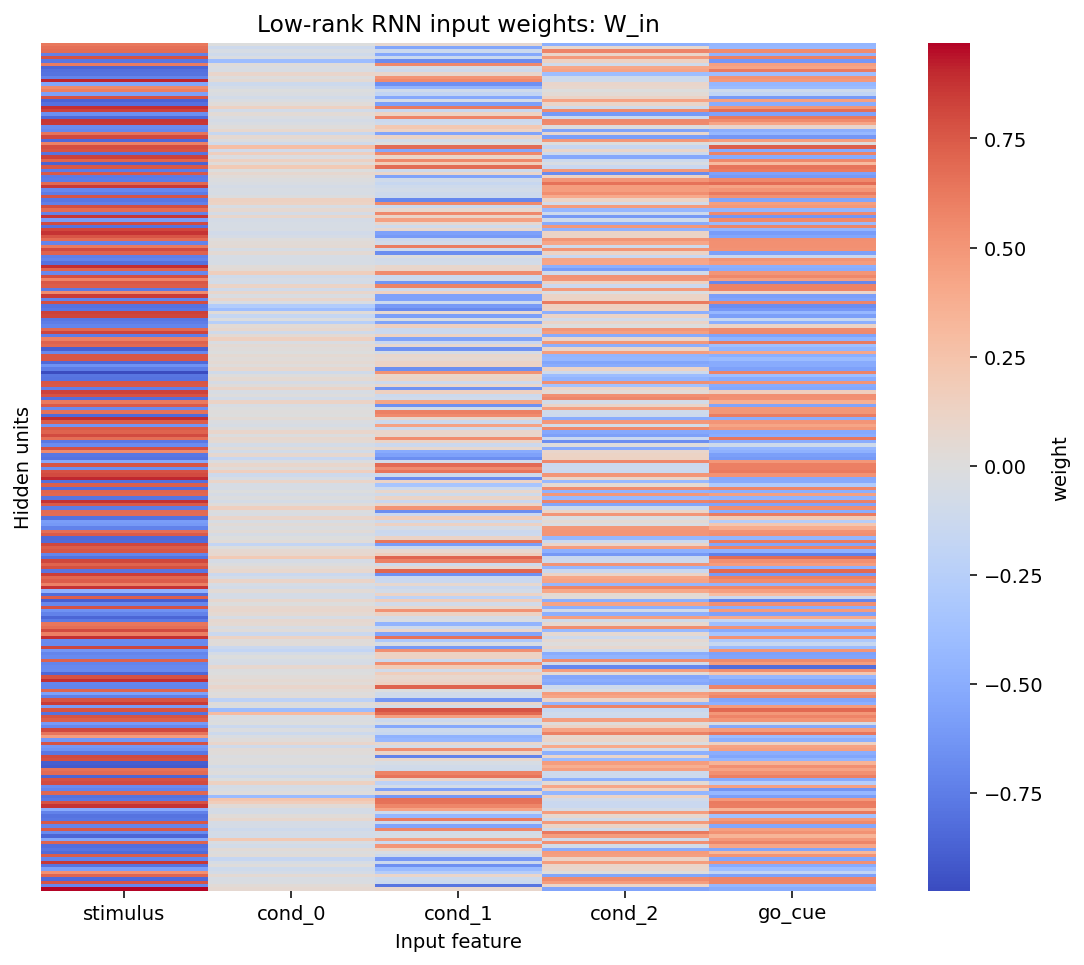

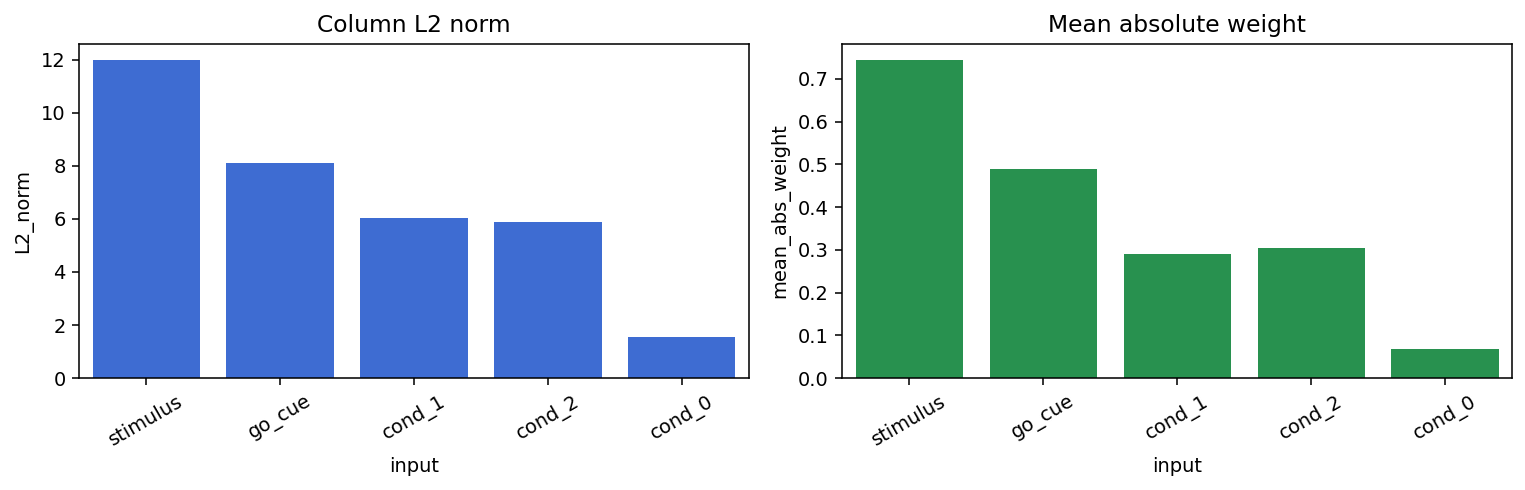

,input,L2_norm,mean_abs_weight
0,stimulus,12.011103,0.745389
4,go_cue,8.099195,0.488510
2,cond_1,6.021575,0.290515
3,cond_2,5.894720,0.303771
1,cond_0,1.540682,0.068192


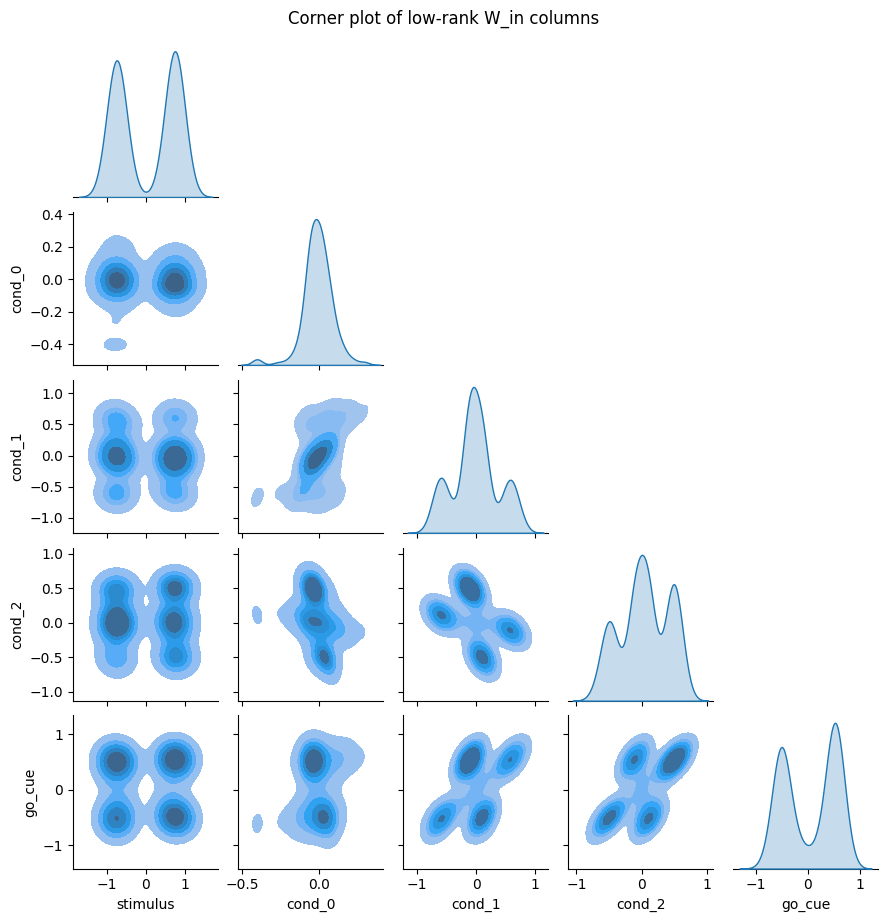

Selectivity distribution: largest absolute W_in column per hidden unit


,input,count,fraction
0,stimulus,249,0.972656
1,cond_0,0,0.000000
2,cond_1,4,0.015625
3,cond_2,1,0.003906
4,go_cue,2,0.007812


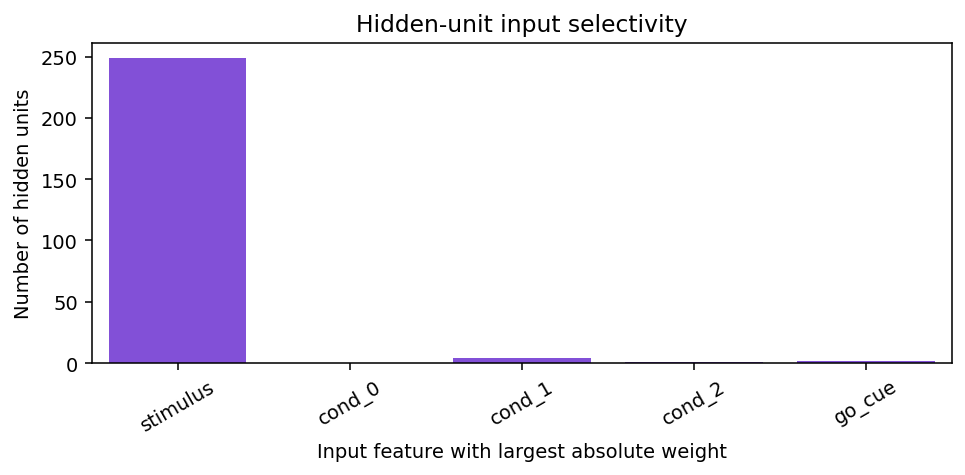

In [ ]:
import seaborn as sns

LOW_RANK_COLUMN_NAMES = ["stimulus", "cond_0", "cond_1", "cond_2", "go_cue"]


def extract_low_rank_state_dict():
    """Return the trained low-rank state dict from the loaded checkpoint."""
    if "model_state_dict" in checkpoints["low_rank"]:
        return checkpoints["low_rank"]["model_state_dict"]
    if "state_dict" in checkpoints["low_rank"]:
        return checkpoints["low_rank"]["state_dict"]
    raise KeyError("Could not find low-rank model state dict in checkpoint.")


def analyze_low_rank_w_in(state_dict, column_names=LOW_RANK_COLUMN_NAMES):
    """Analyze input weights of the trained homework low-rank RNN."""
    if "W_in" not in state_dict:
        raise KeyError("Current homework low-rank model should contain W_in in its state dict.")

    W_in = state_dict["W_in"]
    if isinstance(W_in, T.Tensor):
        W_in = W_in.detach().cpu().numpy()

    if W_in.shape[1] != len(column_names):
        raise ValueError(f"Expected {len(column_names)} input columns, got W_in shape {W_in.shape}.")

    print("W_in shape:", W_in.shape)
    print("Columns:", column_names)

    # 1. Heatmap across hidden units and input features.
    plt.figure(figsize=(8, 7), dpi=140)
    sns.heatmap(
        W_in,
        cmap="coolwarm",
        center=0,
        xticklabels=column_names,
        yticklabels=False,
        cbar_kws={"label": "weight"},
    )
    plt.title("Low-rank RNN input weights: W_in")
    plt.xlabel("Input feature")
    plt.ylabel("Hidden units")
    plt.tight_layout()
    plt.show()

    # 2. Column norm summary.
    col_norms = np.linalg.norm(W_in, axis=0)
    col_abs_mean = np.mean(np.abs(W_in), axis=0)
    summary = pd.DataFrame({
        "input": column_names,
        "L2_norm": col_norms,
        "mean_abs_weight": col_abs_mean,
    }).sort_values("L2_norm", ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), dpi=140)
    sns.barplot(data=summary, x="input", y="L2_norm", ax=axes[0], color="#2563eb")
    axes[0].set_title("Column L2 norm")
    axes[0].tick_params(axis="x", rotation=30)
    sns.barplot(data=summary, x="input", y="mean_abs_weight", ax=axes[1], color="#16a34a")
    axes[1].set_title("Mean absolute weight")
    axes[1].tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()

    display(summary)

    # 3. Corner plot of hidden-unit input weights.
    df = pd.DataFrame(W_in, columns=column_names)
    g = sns.pairplot(
        data=df,
        diag_kind="kde",
        kind="kde",
        corner=True,
        height=1.8,
        plot_kws={"fill": True, "levels": 6, "thresh": 0.05},
    )
    g.fig.suptitle("Corner plot of low-rank W_in columns", y=1.02)
    plt.show()

    # 4. Selectivity: largest absolute input weight for each hidden unit.
    abs_w = np.abs(W_in)
    max_idx = np.argmax(abs_w, axis=1)
    unique, counts = np.unique(max_idx, return_counts=True)
    selectivity = pd.DataFrame({"input": column_names, "count": 0})
    for idx, count in zip(unique, counts):
        selectivity.loc[selectivity["input"] == column_names[idx], "count"] = int(count)
    selectivity["fraction"] = selectivity["count"] / W_in.shape[0]

    print("Selectivity distribution: largest absolute W_in column per hidden unit")
    display(selectivity)

    plt.figure(figsize=(7, 3.5), dpi=140)
    sns.barplot(data=selectivity, x="input", y="count", color="#7c3aed")
    plt.title("Hidden-unit input selectivity")
    plt.xlabel("Input feature with largest absolute weight")
    plt.ylabel("Number of hidden units")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    return W_in, summary, selectivity


low_rank_state_dict = extract_low_rank_state_dict()
W_in_low_rank, W_in_summary, W_in_selectivity = analyze_low_rank_w_in(low_rank_state_dict)

## 9. Additional analysis with the low-rank network

Here is just a more complete connectivity plot, using "kde" method.
Connectivity vectors : stimulus, cond_0/1/2, go_cue, recurrent_selection, recurrent_injection and output

odict_keys(['h0', 'W_in', 'U', 'V', 'W_out'])
dict_keys(['stimulus', 'cond_0', 'cond_1', 'cond_2', 'go_cue', 'output', 'recurrent_injection', 'recurrent_selection', 'copy_invert', 'active_context'])


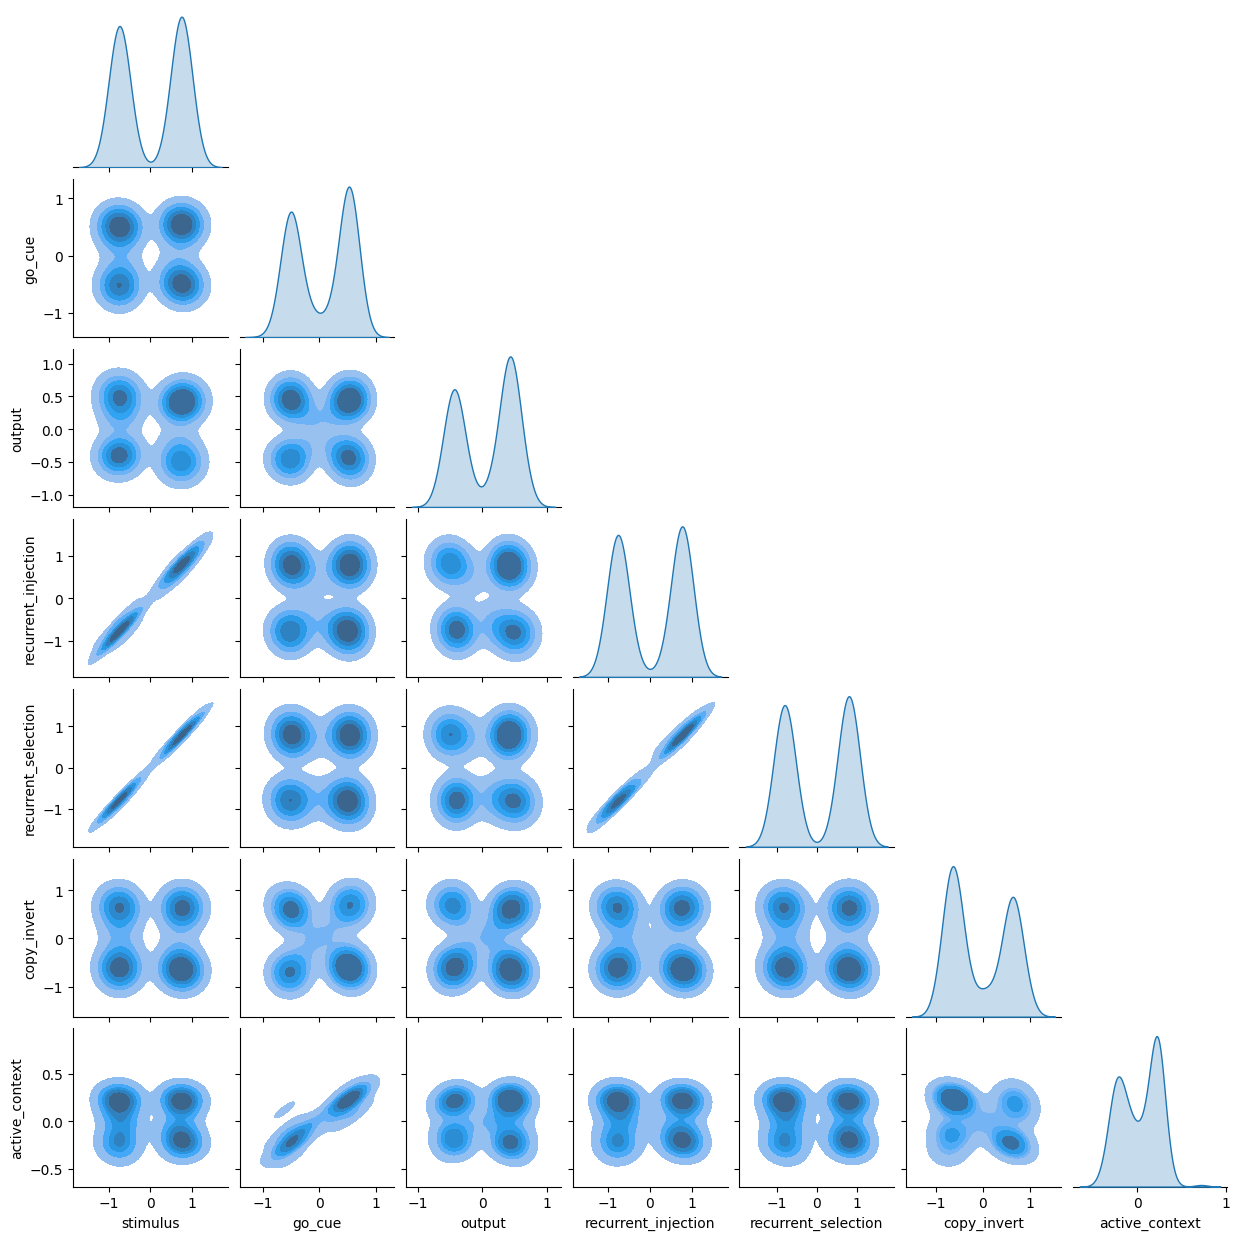

In [ ]:
# @title
name = "low_rank"
model = models[name]
column_names = ["stimulus", "cond_0", "cond_1", "cond_2", "go_cue",
                "recurrent_selection", "recurrent_injection", "output",
                "active_context", "copy_invert"]

def extract_state_dict(name):
    """Return the trained network's state dict from the loaded checkpoint."""
    if "model_state_dict" in checkpoints[name]:
        return checkpoints[name]["model_state_dict"]
    if "state_dict" in checkpoints[name]:
        return checkpoints[name]["state_dict"]
    raise KeyError("Could not find model's state dict in checkpoint.")

state_dict = extract_state_dict(name)
print(state_dict.keys())

def get_low_rank_vectors(state_dict):
    """
    Return a dictionary of named connectivity vectors.

    Each vector is returned as a column matrix with shape [hidden_size, 1].
    """
    def to_np(x):
        if isinstance(x, T.Tensor):
            return x.detach().cpu().numpy()
        return np.asarray(x)

    W_in = to_np(state_dict["W_in"])        # [hidden, 5]
    U = to_np(state_dict["U"])              # [hidden, rank]
    V = to_np(state_dict["V"])              # [hidden, rank]
    W_out = to_np(state_dict["W_out"]).T    # [1, hidden] -> [hidden, 1]

    vectors = {
        "stimulus": W_in[:, 0:1],
        "cond_0": W_in[:, 1:2],
        "cond_1": W_in[:, 2:3],
        "cond_2": W_in[:, 3:4],
        "go_cue": W_in[:, 4:5],
        "output": W_out,
    }

    rank = U.shape[1]

    # Convenient aliases when rank == 1
    if rank == 1:
        vectors["recurrent_injection"] = U[:, 0:1]
        vectors["recurrent_selection"] = V[:, 0:1]
    else :
      for r in range(rank):
          vectors[f"recurrent_injection_{r}"] = U[:, r:r+1]
          vectors[f"recurrent_selection_{r}"] = V[:, r:r+1]



    #Added composites vectors to build dimensions where we can observe the
    #effect of contexts on the low-D dynamic
    vectors["copy_invert"] = vectors["cond_1"] - vectors["cond_2"]

    vectors["active_context"] = (
        0.5 * (vectors["cond_1"] + vectors["cond_2"]) - vectors["cond_0"]
    )

    return vectors

vectors = get_low_rank_vectors(state_dict)
print(vectors.keys())

def corner_plot(name, vectors, column_names=vectors.keys(), clever_plot=False):
  hidden_size = vectors["stimulus"].shape[0]
  L = []
  dict = vectors
  if clever_plot:
    for k in range(3):
      del dict[f"cond_{k}"]
  else:
    del dict["cond_1_minus_cond_2"]
    del dict["active_context_minus_cond_0"]
  for element in vectors.values():
    if isinstance(element, T.Tensor):
        element = element.detach().cpu().numpy()
    L.append(element)
  connectivity_matrix = np.concatenate(L, axis=1)
  df = pd.DataFrame(connectivity_matrix, columns=column_names)
  g = sns.pairplot(
      data=df,
      diag_kind="kde",
      kind="kde",
      corner=True,
      height=1.8,
      plot_kws={"fill": True, "levels": 6, "thresh": 0.05},
  )
  plt.savefig("/content/drive/MyDrive/wykres_na_dysku.png", dpi=300)
  plt.show()
  g.fig.suptitle(f"Corner plot of {name} connectivity columns", y=1.02)
  plt.show()
  return connectivity_matrix

connectivity_matrix = corner_plot(name, vectors, clever_plot=True)

In [ ]:
for name, elements in state_dict.items():
  print(f"{name:9s} | {elements.shape}")

h0        | torch.Size([1, 256])
W_in      | torch.Size([256, 5])
U         | torch.Size([256, 1])
V         | torch.Size([256, 1])
W_out     | torch.Size([1, 256])


Here you can find a function that plot the dynamics of the activity of the networks along every dimensions you want to use in the set of connectivity vectors + some composite vectors we build for readability.

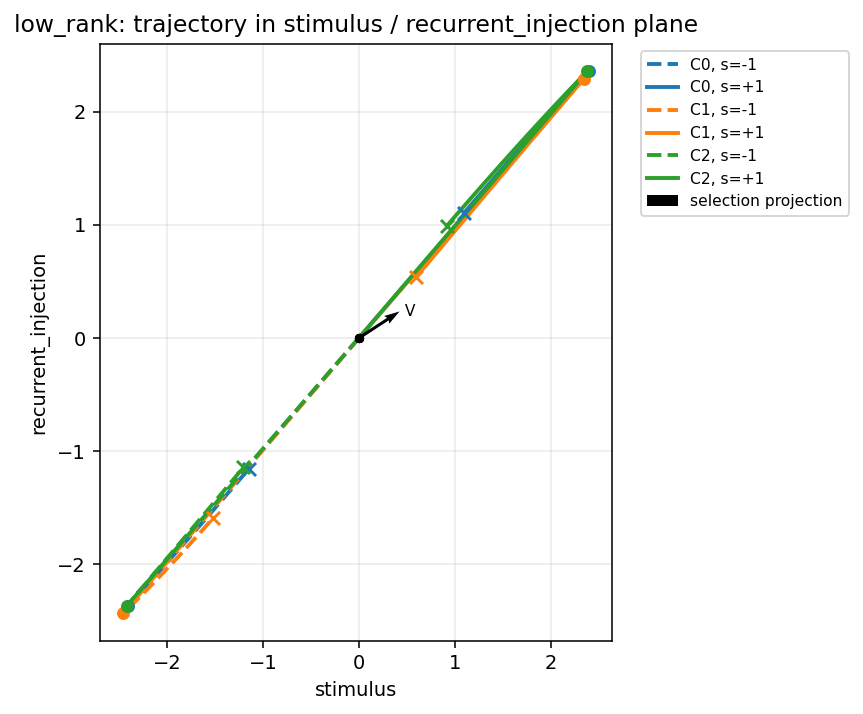

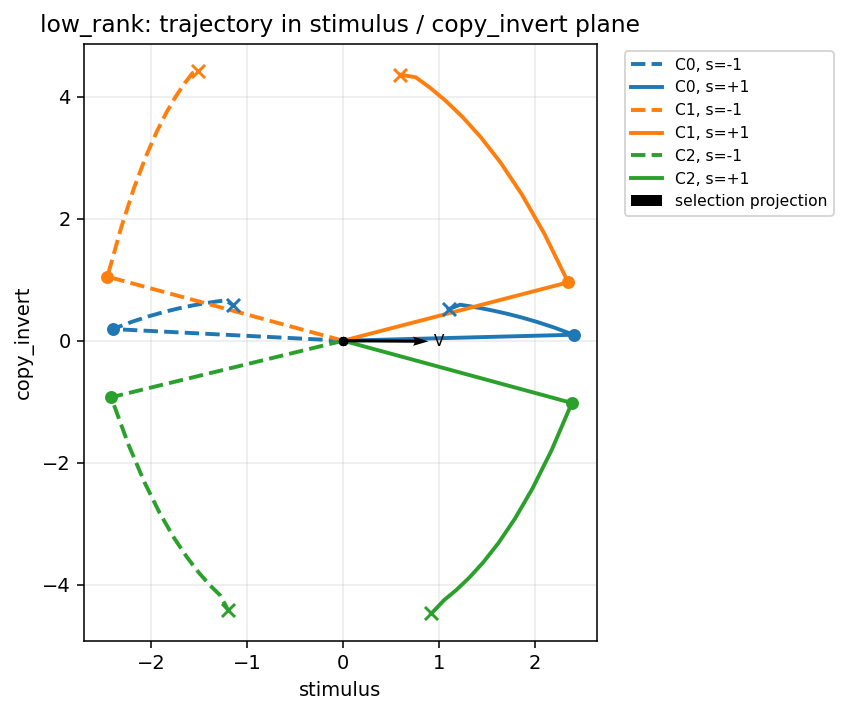

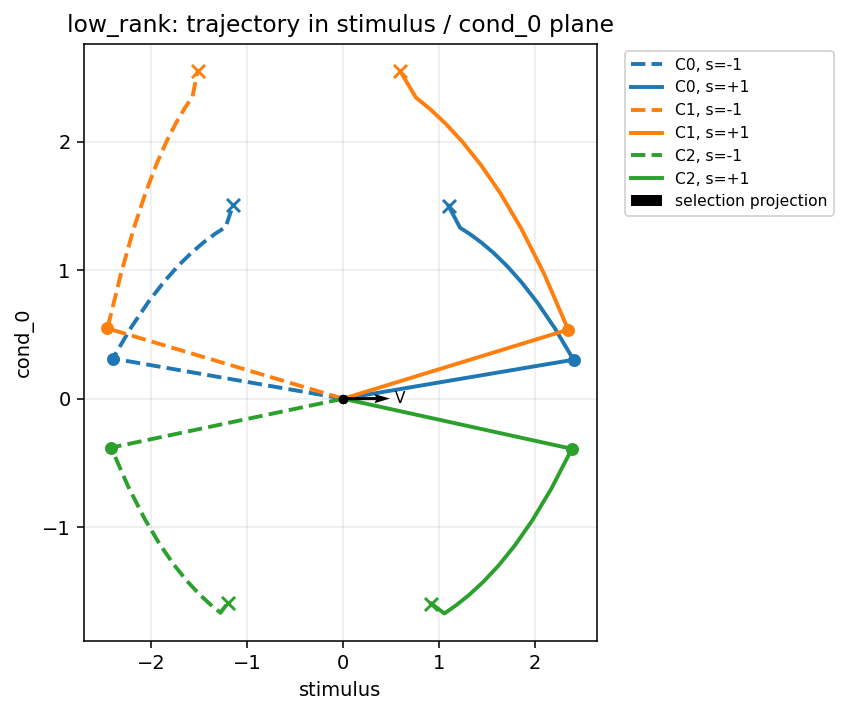

In [ ]:
# @title
# ── 0. Used_functions ────────────────────────────────────────────────────────

def project_on_two_vectors(states, h0, X, Y, mode="overlap", normalize=True):
    """
    Project hidden trajectories onto the 2D subspace/directions defined by X and Y.

    states: torch tensor or numpy array, shape [batch, time, hidden]
    h0:     torch tensor or numpy array, shape [1, hidden]
    X, Y:   numpy arrays, each shape [hidden, 1]

    mode:
        "overlap" -> coordinates are dot products with X and Y.
        "basis"   -> coordinates are least-squares coefficients in basis [X, Y].
    """
    if isinstance(states, T.Tensor):
        states_np = states.detach().cpu().numpy()
    else:
        states_np = np.asarray(states)

    if isinstance(h0, T.Tensor):
        h0_np = h0.detach().cpu().numpy()
    else:
        h0_np = np.asarray(h0)

    X_states = states_np.reshape(-1, states_np.shape[-1])  # [batch*time, hidden]
    X_all = np.concatenate([h0_np, X_states], axis=0)       # [1 + batch*time, hidden]

    B = np.concatenate([X, Y], axis=1)                      # [hidden, 2]

    if normalize:
        B = B / (np.linalg.norm(B, axis=0, keepdims=True) + 1e-12)

    if mode == "overlap":
        Z_all = X_all @ B

    elif mode == "basis":
        # Coordinates c such that state ≈ c_1 X + c_2 Y
        Z_all = X_all @ B @ np.linalg.pinv(B.T @ B)

    else:
        raise ValueError("mode must be either 'overlap' or 'basis'.")

    Z_h0 = Z_all[0]
    Z_states = Z_all[1:].reshape(states_np.shape[0], states_np.shape[1], 2)

    return Z_states, Z_h0

def plot_low_rank_trajectory_in_connectivity_plane(
    model,
    model_name,
    name_X,
    name_Y,
    repeats_per_case=1,
    projection_mode="overlap",
    normalize_vectors=True,
    device=DEVICE,
    return_data=False,
):
    """
    Plot the hidden-state trajectory of one low-rank model in the plane defined
    by two chosen connectivity vectors.

    Example:
        plot_low_rank_trajectory_in_connectivity_plane(
            models["low_rank"],
            "low_rank",
            "stimulus",
            "output",
        )
    """
    model.eval()

    # 1. Build a balanced test batch.
    task = ContextGoNoGoTask(seq_len=model_args[model_name].seq_len)
    inputs, targets, contexts, stimuli = task.make_balanced_batch(
        repeats_per_case,
        device,
    )

    # 2. Run the model and collect hidden states.
    with T.no_grad():
        outputs, states = model(inputs, return_states=True)

    # 3. Get initial hidden state h0.
    # For low-rank/full-rank RNNs, this is model.h0.
    h0 = model.h0.detach().cpu()  # [1, hidden]

    # 4. Extract named connectivity vectors.
    state_dict = extract_state_dict(model_name)
    vectors = get_low_rank_vectors(state_dict)

    if name_X not in vectors:
        raise KeyError(f"Unknown X vector '{name_X}'. Available: {list(vectors.keys())}")

    if name_Y not in vectors:
        raise KeyError(f"Unknown Y vector '{name_Y}'. Available: {list(vectors.keys())}")

    X = vectors[name_X]
    Y = vectors[name_Y]

    V = state_dict["V"]
    if isinstance(V, T.Tensor):
      V = V.detach().cpu().numpy()
    V = np.asarray(V)

    if V.ndim == 1:
        V = V[None, :]        # [1, hidden]
    elif V.shape[1] == 1:
        V = V.T               # [hidden, 1] -> [1, hidden]

    # 5. Project states,h0 and recurrent selection vector V in the chosen 2D plane.
    Z, Z_h0 = project_on_two_vectors(
        states=states,
        h0=h0,
        X=X,
        Y=Y,
        mode=projection_mode,
        normalize=normalize_vectors,
    )

    B = np.concatenate([X, Y], axis=1)  # [hidden, 2]
    B = B / (np.linalg.norm(B, axis=0, keepdims=True) + 1e-12)
    V_z = V @ B @ np.linalg.pinv(B.T @ B)
    V_z  = V_z.squeeze()

    # 6. Convert conditions to numpy for masking.
    contexts_np = contexts.detach().cpu().numpy()
    stimuli_np = stimuli.detach().cpu().numpy()

    colors = {
        0: "C0",
        1: "C1",
        2: "C2",
    }

    linestyles = {
        -1.0: "--",
        1.0: "-",
    }

    fig, ax = plt.subplots(figsize=(6.2, 5.2), dpi=140)

    for context_id in range(task.num_contexts):
        for stimulus_value in (-1.0, 1.0):
            mask = (
                (contexts_np == context_id)
                & (stimuli_np == stimulus_value)
            )

            if not np.any(mask):
                continue

            # Z[mask] has shape [n_repeats, time, 2].
            # We average repeated trials after projection.
            traj = Z[mask].mean(axis=0)  # [time, 2]

            # Add h0 as the pre-trial point.
            traj_with_h0 = np.vstack([Z_h0[None, :], traj])  # [time+1, 2]

            ax.plot(
                traj_with_h0[:, 0],
                traj_with_h0[:, 1],
                color=colors[context_id],
                ls=linestyles[stimulus_value],
                lw=2,
                label=f"C{context_id}, s={int(stimulus_value):+d}",
            )

            # h0 point
            ax.scatter(
                traj_with_h0[0, 0],
                traj_with_h0[0, 1],
                color="black",
                marker=".",
                s=55,
                zorder=5,
            )

            # first post-input state
            ax.scatter(
                traj_with_h0[1, 0],
                traj_with_h0[1, 1],
                color=colors[context_id],
                marker="o",
                s=32,
                zorder=5,
            )

            # final state
            ax.scatter(
                traj_with_h0[-1, 0],
                traj_with_h0[-1, 1],
                color=colors[context_id],
                marker="x",
                s=45,
                zorder=5,
            )

      # Draw readout projection as an arrow.
    arrow_origin = np.array([0.0, 0.0])

    # Rescale only for visibility.
    plot_range = max(
      np.ptp(Z[:, :, 0]),
      np.ptp(Z[:, :, 1]),
      1e-12,
    )

    readout_norm = np.linalg.norm(V_z) + 1e-12
    arrow_length = 0.1 * plot_range
    readout_arrow = V_z / readout_norm * arrow_length

    ax.quiver(
      arrow_origin[0],
      arrow_origin[1],
      readout_arrow[0],
      readout_arrow[1],
      angles="xy",
      scale_units="xy",
      scale=1,
      color="black",
      width=0.006,
      label="selection projection",
      zorder=10,
    )

    ax.text(
      arrow_origin[0] + readout_arrow[0],
      arrow_origin[1] + readout_arrow[1],
      " V",
      color="black",
      fontsize=8,
      ha="left",
      va="center",
    )

    ax.set_title(f"{model_name}: trajectory in {name_X} / {name_Y} plane")
    ax.set_xlabel(name_X)
    ax.set_ylabel(name_Y)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8, bbox_to_anchor=(1.04, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

    if return_data:
        return {
            "Z_states": Z,
            "Z_h0": Z_h0,
            "outputs": outputs.detach().cpu(),
            "states": states.detach().cpu(),
            "inputs": inputs.detach().cpu(),
            "targets": targets.detach().cpu(),
            "contexts": contexts.detach().cpu(),
            "stimuli": stimuli.detach().cpu(),
            "vectors": vectors,
        }

# ── 1. Making_plots ────────────────────────────────────────────────────────

plot_low_rank_trajectory_in_connectivity_plane(
    model=models["low_rank"],
    model_name="low_rank",
    name_X="stimulus",
    name_Y="recurrent_injection",
    repeats_per_case=1,
)

plot_low_rank_trajectory_in_connectivity_plane(
    model=models["low_rank"],
    model_name="low_rank",
    name_X="stimulus",
    name_Y="copy_invert",
    repeats_per_case=1,
)

plot_low_rank_trajectory_in_connectivity_plane(
    model=models["low_rank"],
    model_name="low_rank",
    name_X="stimulus",
    name_Y="cond_0",
    repeats_per_case=1,
)

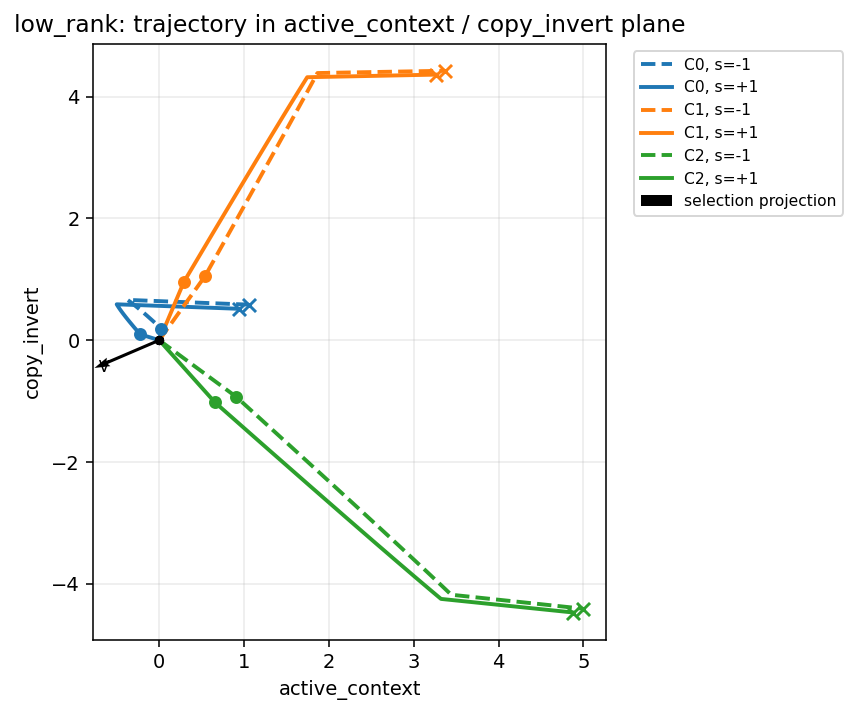

In [ ]:
plot_low_rank_trajectory_in_connectivity_plane(
    model=models["low_rank"],
    model_name="low_rank",
    name_X="active_context",
    name_Y="copy_invert",
    repeats_per_case=1,
)

Here We plotted the dynamics of kappa(r) by making a readout of the network activity with the selection_recurrent vector at each timestep. The equivalent of output plot you did Ulysse, but with the latent variable we cared about.

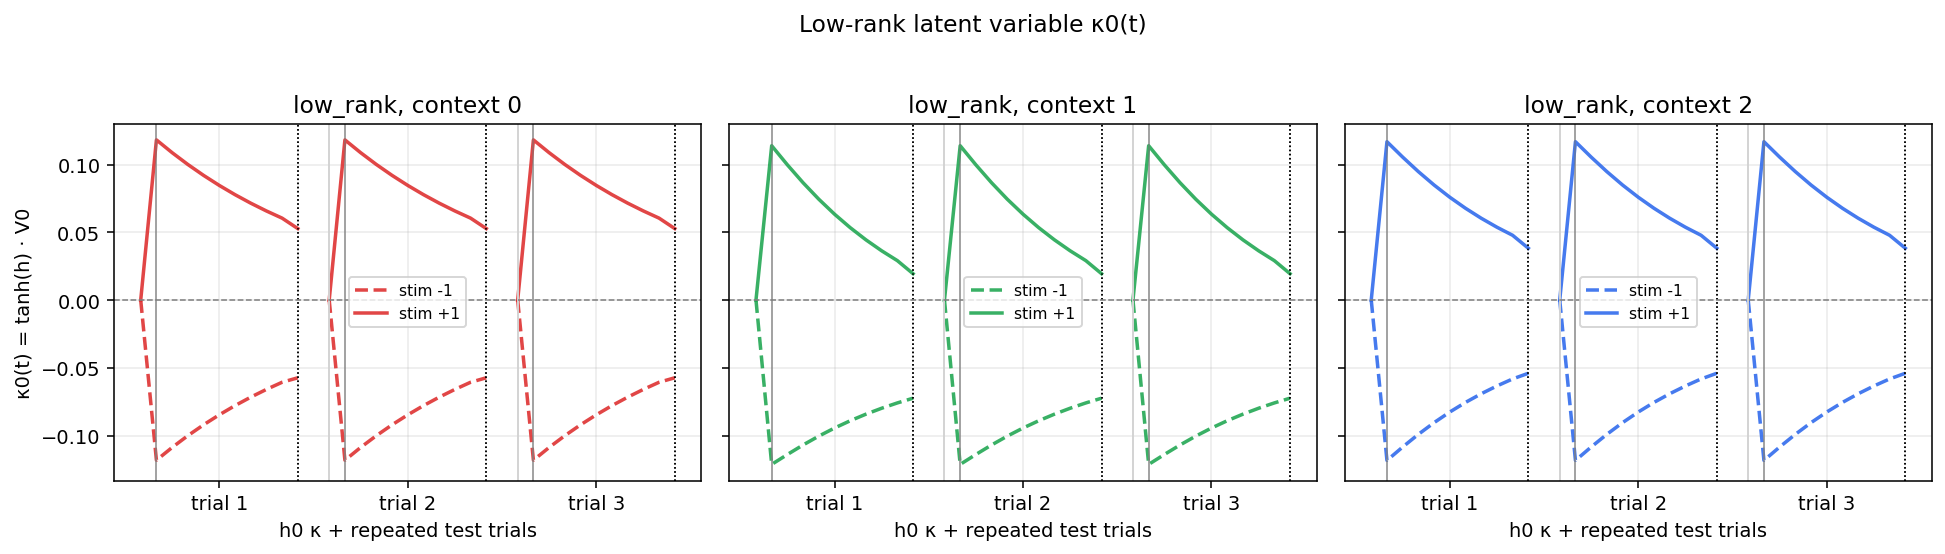

In [ ]:
# @title
colors = {0: "#dc2626", 1: "#16a34a", 2: "#2563eb"}
linestyles = {-1: "--", 1: "-"}


def low_rank_initial_kappa(model, state_dict, component=0, divide_by_hidden=True):
    """
    Compute κ(0) from the default initial state h0.

    κ_r(0) = tanh(h0) @ V_r
    Optionally divided by hidden_size to match the 1/N low-rank scaling.
    """
    with T.no_grad():
        h0 = model.h0.detach().cpu()  # [1, hidden]

        V = state_dict["V"].detach().cpu()  # [hidden, rank]
        v = V[:, component:component + 1]   # [hidden, 1]

        rates0 = T.tanh(h0)                 # [1, hidden]
        kappa0 = rates0 @ v                 # [1, 1]

        if divide_by_hidden:
            kappa0 = kappa0 / model.hidden_size

        return float(kappa0.squeeze())


def low_rank_kappa_from_states(model, state_dict, states, component=0, divide_by_hidden=True):
    """
    Compute κ_r(t) over all trials and timesteps.

    states: [batch, time, hidden]
    returns: [batch, time]
    """
    with T.no_grad():
        if not isinstance(states, T.Tensor):
            states = T.tensor(states)

        states = states.detach().cpu()

        V = state_dict["V"].detach().cpu()  # [hidden, rank]
        v = V[:, component:component + 1]   # [hidden, 1]

        rates = T.tanh(states)              # [batch, time, hidden]
        kappa = rates @ v                   # [batch, time, 1]
        kappa = kappa.squeeze(-1)           # [batch, time]

        if divide_by_hidden:
            kappa = kappa / model.hidden_size

        return kappa.numpy()

name = "low_rank"
model = models[name]
state_dict = extract_state_dict(name)
res = results[name]
component = 0
divide_by_hidden = True

kappa = low_rank_kappa_from_states(
    model=model,
    state_dict=state_dict,
    states=res["states"],
    component=component,
    divide_by_hidden=divide_by_hidden,
)

kappa0 = low_rank_initial_kappa(
    model=model,
    state_dict=state_dict,
    component=component,
    divide_by_hidden=divide_by_hidden,
)

trial_len = task.seq_len
gap = 1

# Add one pre-trial timestep at x=-1 for h0 κ.
pre_len = 1
plot_trial_len = trial_len + pre_len
trial_stride = plot_trial_len + gap

trial_x = np.arange(-1, trial_len)
real_trial_x = np.arange(trial_len)
trial_centers = [
    (trial_x.mean() + k * trial_stride)
    for k in range(TEST_REPEATS_PER_CASE)
]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharex=True, sharey=True, dpi=140)

for context_id in range(3):
    ax = axes[context_id]

    for stimulus in (-1, 1):
        mask = (
            (contexts.cpu().numpy() == context_id)
            & (stimuli.cpu().numpy() == stimulus)
        )

        trial_indices = np.where(mask)[0][:TEST_REPEATS_PER_CASE]

        for repeat_i, trial_idx in enumerate(trial_indices):
            x = trial_x + repeat_i * trial_stride

            # Prepend κ from h0 at t=-1.
            y = np.concatenate([[kappa0], kappa[trial_idx]])

            label = f"stim {stimulus:+d}" if repeat_i == 0 else None

            ax.plot(
                x,
                y,
                color=colors[context_id],
                ls=linestyles[stimulus],
                lw=1.8,
                alpha=0.85,
                label=label,
            )

            # Mark stimulus onset t=0.
            ax.axvline(
                0 + repeat_i * trial_stride,
                color="grey",
                ls="-",
                lw=0.8,
                alpha=0.6,
            )

            # Mark go cue / decision timestep.
            ax.axvline(
                task.go_cue_t + repeat_i * trial_stride,
                color="black",
                ls=":",
                lw=0.8,
            )

    for repeat_i in range(1, TEST_REPEATS_PER_CASE):
        ax.axvline(
            repeat_i * trial_stride - gap,
            color="lightgrey",
            lw=1.0,
        )

    ax.axhline(0.0, color="grey", ls="--", lw=0.8)

    ax.set_title(f"{name}, context {context_id}")
    ax.set_xticks(
        trial_centers,
        [f"trial {i + 1}" for i in range(TEST_REPEATS_PER_CASE)],
    )

    ax.grid(True, alpha=0.25)
    ax.set_xlabel("h0 κ + repeated test trials")

    if context_id == 0:
        ax.set_ylabel(f"κ{component}(t) = tanh(h) · V{component}")

    ax.legend(fontsize=8)

plt.suptitle(f"Low-rank latent variable κ{component}(t)", y=1.03)
plt.tight_layout()
plt.show()

Here is a second version of the same code that chatGPT proposed me to see the temporal alignment with the stimulus and context timeseries because the previous plots were hard to interpret. I didn't have the time to check it so be careful when you use it.

In [ ]:
# @title
colors = {0: "#dc2626", 1: "#16a34a", 2: "#2563eb"}
linestyles = {-1: "--", 1: "-"}


def low_rank_initial_kappa(model, state_dict, component=0, divide_by_hidden=True):
    """
    Compute κ_r before any input, from h0.

    κ_r(0) = tanh(h0) @ V_r
    optionally divided by hidden_size to match the low-rank 1/N scaling.
    """
    with T.no_grad():
        h0 = model.h0.detach().cpu()             # [1, hidden]
        V = state_dict["V"].detach().cpu()       # [hidden, rank]
        v = V[:, component:component + 1]        # [hidden, 1]

        rates0 = T.tanh(h0)                      # [1, hidden]
        kappa0 = rates0 @ v                      # [1, 1]

        if divide_by_hidden:
            kappa0 = kappa0 / model.hidden_size

        return float(kappa0.squeeze())


def low_rank_kappa_from_states(model, state_dict, states, component=0, divide_by_hidden=True):
    """
    Compute κ_r(t) from hidden states.

    states: [batch, time, hidden]
    returns: [batch, time]
    """
    with T.no_grad():
        if isinstance(states, T.Tensor):
            states_t = states.detach().cpu()
        else:
            states_t = T.tensor(states).detach().cpu()

        V = state_dict["V"].detach().cpu()       # [hidden, rank]
        v = V[:, component:component + 1]        # [hidden, 1]

        rates = T.tanh(states_t)                 # [batch, time, hidden]
        kappa = rates @ v                        # [batch, time, 1]
        kappa = kappa.squeeze(-1)                # [batch, time]

        if divide_by_hidden:
            kappa = kappa / model.hidden_size

        return kappa.numpy()

In [ ]:
# @title
def plot_low_rank_kappa_with_stimulus(
    model,
    name,
    results,
    inputs,
    contexts,
    stimuli,
    task,
    TEST_REPEATS_PER_CASE,
    component=0,
    divide_by_hidden=True,
):
    """
    Plot κ_r(t) on the first row and stimulus(t) on the second row,
    aligned trial by trial and context by context.
    """
    state_dict = extract_state_dict(name)

    states = results[name]["states"]

    kappa = low_rank_kappa_from_states(
        model=model,
        state_dict=state_dict,
        states=states,
        component=component,
        divide_by_hidden=divide_by_hidden,
    )

    kappa0 = low_rank_initial_kappa(
        model=model,
        state_dict=state_dict,
        component=component,
        divide_by_hidden=divide_by_hidden,
    )

    # Stimulus channel is channel 0: [stimulus, cond_0, cond_1, cond_2, go_cue]
    stimulus_trace = inputs[:, :, 0].detach().cpu().numpy()

    contexts_np = contexts.detach().cpu().numpy()
    stimuli_np = stimuli.detach().cpu().numpy()

    trial_len = task.seq_len
    gap = 1

    # Add one pre-trial timestep at x=-1 for h0 / pre-input value.
    pre_len = 1
    plot_trial_len = trial_len + pre_len
    trial_stride = plot_trial_len + gap

    trial_x = np.arange(-1, trial_len)
    trial_centers = [
        (trial_x.mean() + k * trial_stride)
        for k in range(TEST_REPEATS_PER_CASE)
    ]

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(14, 6.5),
        sharex=True,
        dpi=140,
        gridspec_kw={"height_ratios": [2.0, 1.0]},
    )

    for context_id in range(3):
        ax_kappa = axes[0, context_id]
        ax_stim = axes[1, context_id]

        for stimulus_value in (-1, 1):
            mask = (
                (contexts_np == context_id)
                & np.isclose(stimuli_np, stimulus_value)
            )

            trial_indices = np.where(mask)[0][:TEST_REPEATS_PER_CASE]

            for repeat_i, trial_idx in enumerate(trial_indices):
                x = trial_x + repeat_i * trial_stride

                # κ(t), with pre-trial κ0 at x=-1.
                y_kappa = np.concatenate([[kappa0], kappa[trial_idx]])

                # stimulus(t), with pre-trial stimulus = 0 at x=-1.
                y_stim = np.concatenate([[0.0], stimulus_trace[trial_idx]])

                label = f"stim {stimulus_value:+d}" if repeat_i == 0 else None

                ax_kappa.plot(
                    x,
                    y_kappa,
                    color=colors[context_id],
                    ls=linestyles[stimulus_value],
                    lw=1.8,
                    alpha=0.85,
                    label=label,
                )

                ax_stim.step(
                    x,
                    y_stim,
                    where="post",
                    color=colors[context_id],
                    ls=linestyles[stimulus_value],
                    lw=1.8,
                    alpha=0.85,
                    label=label,
                )

                ax_stim.scatter(
                    x,
                    y_stim,
                    color=colors[context_id],
                    s=12,
                    alpha=0.75,
                )

                # Mark stimulus onset t=0 and go cue / decision timestep.
                for ax in (ax_kappa, ax_stim):
                    ax.axvline(
                        0 + repeat_i * trial_stride,
                        color="grey",
                        ls="-",
                        lw=0.8,
                        alpha=0.6,
                    )

                    ax.axvline(
                        task.go_cue_t + repeat_i * trial_stride,
                        color="black",
                        ls=":",
                        lw=0.8,
                    )

        # Separators between repeated trials.
        for repeat_i in range(1, TEST_REPEATS_PER_CASE):
            for ax in (ax_kappa, ax_stim):
                ax.axvline(
                    repeat_i * trial_stride - gap,
                    color="lightgrey",
                    lw=1.0,
                )

        ax_kappa.axhline(0.0, color="grey", ls="--", lw=0.8)
        ax_stim.axhline(0.0, color="grey", ls="--", lw=0.8)

        ax_kappa.set_title(f"{name}, context {context_id}")
        ax_stim.set_xticks(
            trial_centers,
            [f"trial {i + 1}" for i in range(TEST_REPEATS_PER_CASE)],
        )

        ax_kappa.grid(True, alpha=0.25)
        ax_stim.grid(True, alpha=0.25)

        ax_stim.set_ylim(-1.2, 1.2)

        if context_id == 0:
            ax_kappa.set_ylabel(f"κ{component}(t)")
            ax_stim.set_ylabel("stimulus(t)")

        ax_stim.set_xlabel("aligned repeated test trials")

        ax_kappa.legend(fontsize=8)
        ax_stim.legend(fontsize=8)

    fig.suptitle(
        f"Low-rank latent variable κ{component}(t) and stimulus input over time",
        y=1.02,
    )

    plt.tight_layout()
    plt.show()

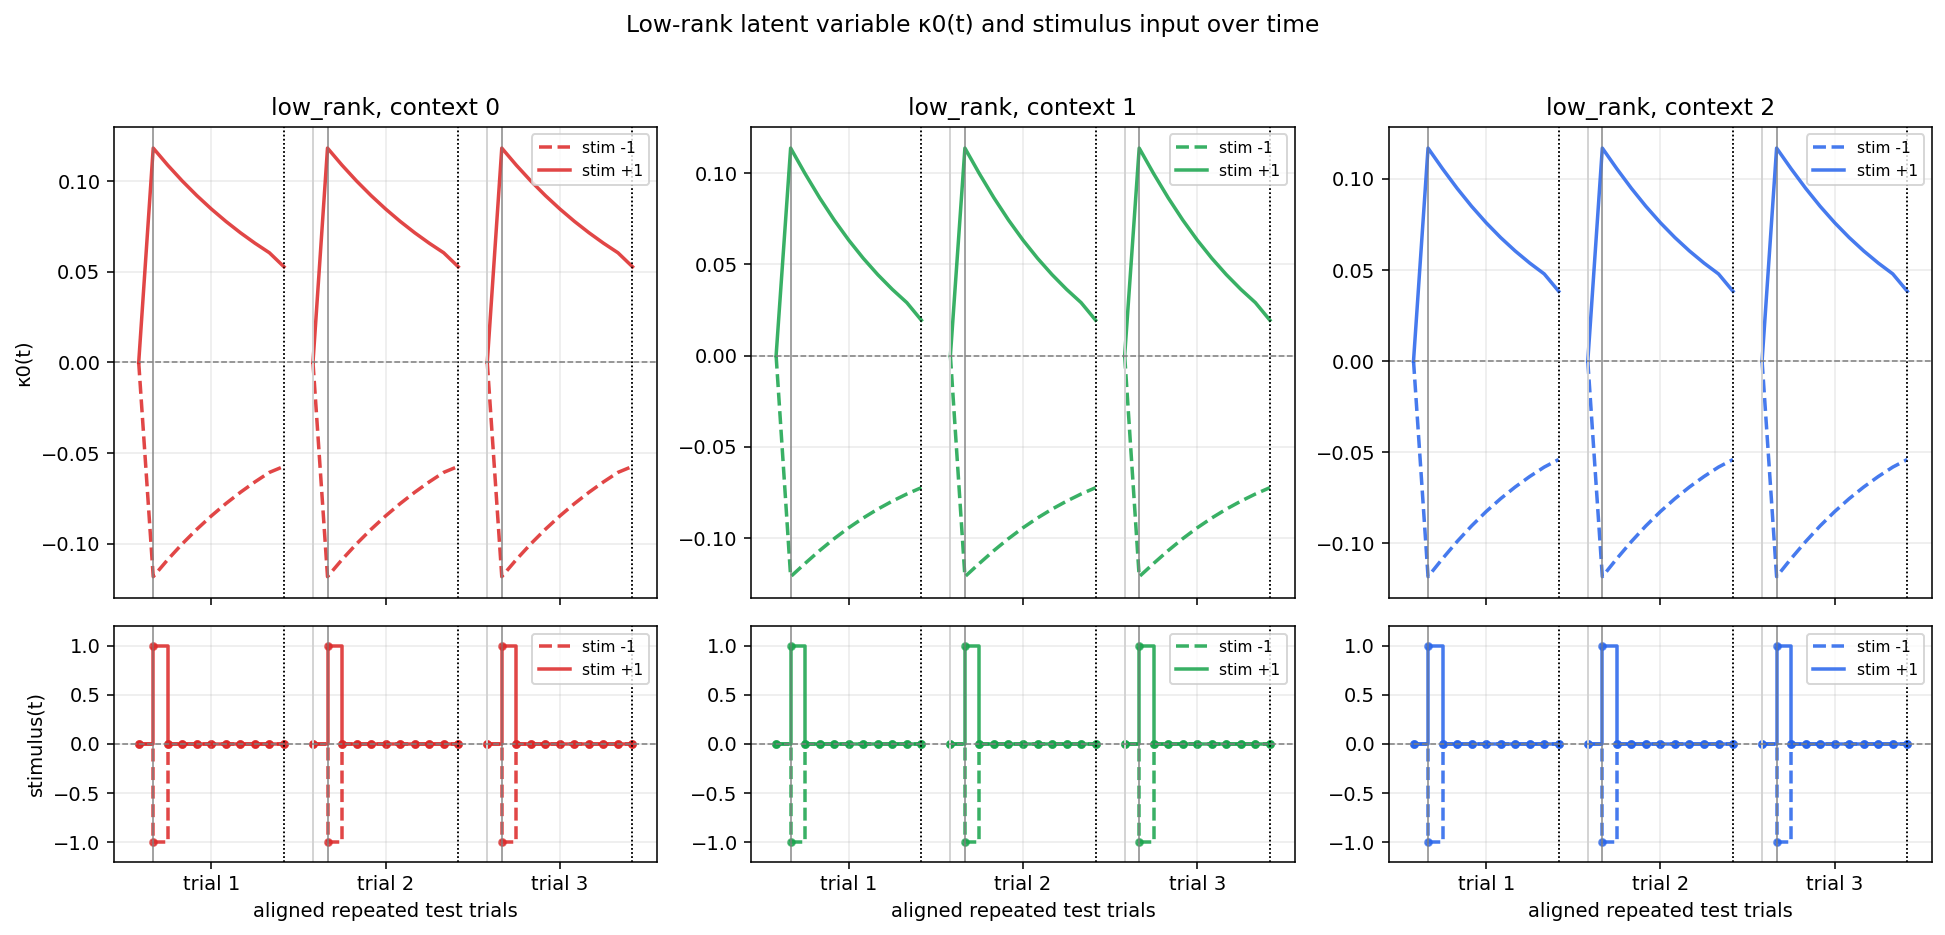

In [ ]:
# @title
plot_low_rank_kappa_with_stimulus(
    model=models["low_rank"],
    name="low_rank",
    results=results,
    inputs=inputs,
    contexts=contexts,
    stimuli=stimuli,
    task=task,
    TEST_REPEATS_PER_CASE=TEST_REPEATS_PER_CASE,
    component=0,
    divide_by_hidden=True,
)

Here I tried to make selectivity plots

In [ ]:
name = "low_rank"
model = models[name]
state_dict = extract_state_dict(name)
hidden_size = model.hidden_size

In [ ]:
# @title
# ── 0. Buiding of the dataset ────────────────────────────────────────────────

# 1. Build a balanced test batch.
repeats_per_case = 1
task = ContextGoNoGoTask(seq_len=model_args[name].seq_len)
inputs, targets, contexts, stimuli = task.make_balanced_batch(repeats_per_case,
    DEVICE,
)

# 2. Run the model, collect firing rates and average them accross each trial.
with T.no_grad():
    outputs, states = model(inputs, return_states=True)

rates = T.tanh(states).detach().cpu().numpy()
rates_mean = rates.mean(axis = 1)

# ── 1. Compute the regression (basic) ────────────────────────────────────────

# 3. Build the components of regression (basic version)
stimuli = stimuli.detach().cpu().numpy()
contexts = contexts.detach().cpu().numpy().astype(float)
intercept = np.ones_like(stimuli)

X = np.column_stack((intercept, stimuli, contexts))
y = rates_mean
beta, residuals, rank, s = np.linalg.lstsq(X, rates_mean, rcond=None)

# 4. Stock the results in a dataframe
regression_df_basic = pd.DataFrame({
    "intercept" : beta[0],
    "stimulus_beta" : beta[1],
    "context_beta" : beta[2]
})

# ── 1. Compute the regression (with interaction terms) ───────────────────────
X = np.column_stack((intercept, stimuli, contexts, stimuli * contexts))
y = rates_mean
beta, residuals, rank, s = np.linalg.lstsq(X, rates_mean, rcond=None)

regression_df_interaction = pd.DataFrame({
    "intercept" : beta[0],
    "stimulus_beta" : beta[1],
    "context_beta" : beta[2],
    "stimulus_context_interaction" : beta[3]
})

# ── 2. Compute the regression (interaction terms + decomposing context) ──────
contexts = contexts.astype(int)
context_1 = (contexts == 1).astype(float)
context_2 = (contexts == 2).astype(float)
context_0 = (contexts == 0).astype(float)

# Effect coding / centered context variables
C1_eff = context_1 - context_0
C2_eff = context_2 - context_0

X = np.column_stack((
    intercept,
    stimuli,
    C1_eff,
    C2_eff,
    C1_eff * stimuli,
    C2_eff * stimuli,
))
y = rates_mean
beta, residuals, rank, s = np.linalg.lstsq(X, rates_mean, rcond=None)

regression_df_complete = pd.DataFrame({
    "intercept" : beta[0],
    "stimulus_beta" : beta[1],
    "C1_beta" : beta[2],
    "C2_beta" : beta[3],
    "stimulus_C1_interaction" : beta[4],
    "stimulus_C2_interaction" : beta[5],
})

# ── 3. Compute the regression (active contexts + C1 Vs C2 effect) ────────────
# Reconfigure the contextual features of the task into two relevant dimensions
active = context_1 + context_2 - context_0
rule = context_1 - context_2

X = np.column_stack((
    intercept,
    stimuli,
    active,
    rule,
    active * stimuli,
    rule * stimuli,
))

y = rates_mean
beta, residuals, rank, s = np.linalg.lstsq(X, rates_mean, rcond=None)

regression_df_clever = pd.DataFrame({
    "intercept" : beta[0],
    "stimulus_beta" : beta[1],
    "active_beta" : beta[2],
    "rule_beta" : beta[3],
    "stimuli_activation" : beta[4],
    "copy_inverse_stimuli" : beta[5],
})

In [ ]:
print(rates_mean.shape)
print(contexts)
print(stimuli)
print(beta.shape)

(6, 256)
[0 0 1 1 2 2]
[-1.  1. -1.  1. -1.  1.]
(6, 256)


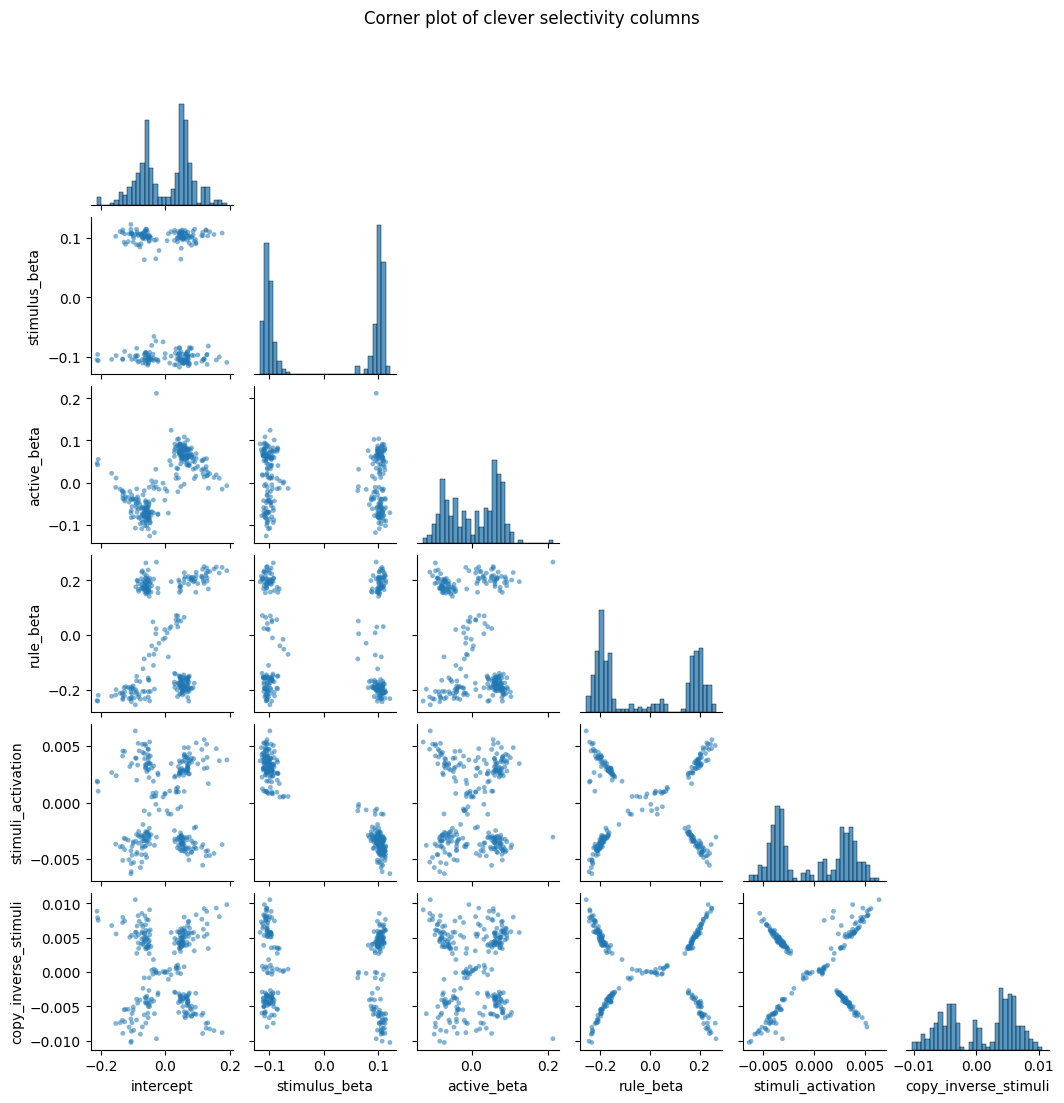

In [ ]:
# @title
# 5. Make selectivity plots
def plot_selectivity_plots(regression_df, name):
  g = sns.pairplot(
      data=regression_df,
      diag_kind="hist",
      kind="scatter",
      corner=True,
      height=1.8,
      plot_kws={"s": 12, "alpha": 0.55, "edgecolor": "none"},
      diag_kws={"bins": 30},
  )
  g.fig.suptitle(f"Corner plot of {name} selectivity columns", y=1.02)
  plt.show()

#plot_selectivity_plots(regression_df_basic, "basic")
#plot_selectivity_plots(regression_df_interaction, "interaction")
#plot_selectivity_plots(regression_df_complete, "complete")
plot_selectivity_plots(regression_df_clever, "clever")

I added the correlation plots of my regression coefficients to assess the validity of the selectivity space.

In [ ]:
# @title
def correlation_plot_regression_coefficients(regression_df, name=None):
  selectivity_cols = regression_df.columns
  B = regression_df.to_numpy()

  corr = np.corrcoef(B.T)
  corr_df = pd.DataFrame(corr, index=selectivity_cols, columns=selectivity_cols)

  plt.figure(dpi=140)

  sns.heatmap(
      corr_df,
      annot=True,
      fmt=".2f",
      cmap="vlag",
      vmin=-1,
      vmax=1,
      center=0,
      square=True,
      linewidths=0.5,
      cbar_kws={"label": "Pearson correlation"},
  )

  plt.title(f"Correlation matrix of regression coefficients : {name}")
  plt.xticks(rotation=45, ha="right")
  plt.yticks(rotation=0)
  plt.tight_layout()
  plt.show()

  return corr_df

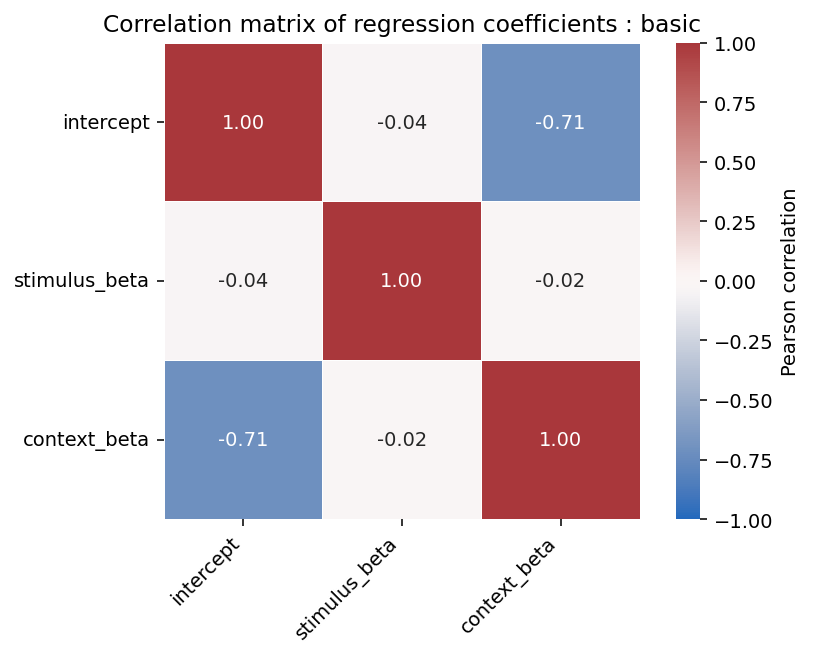

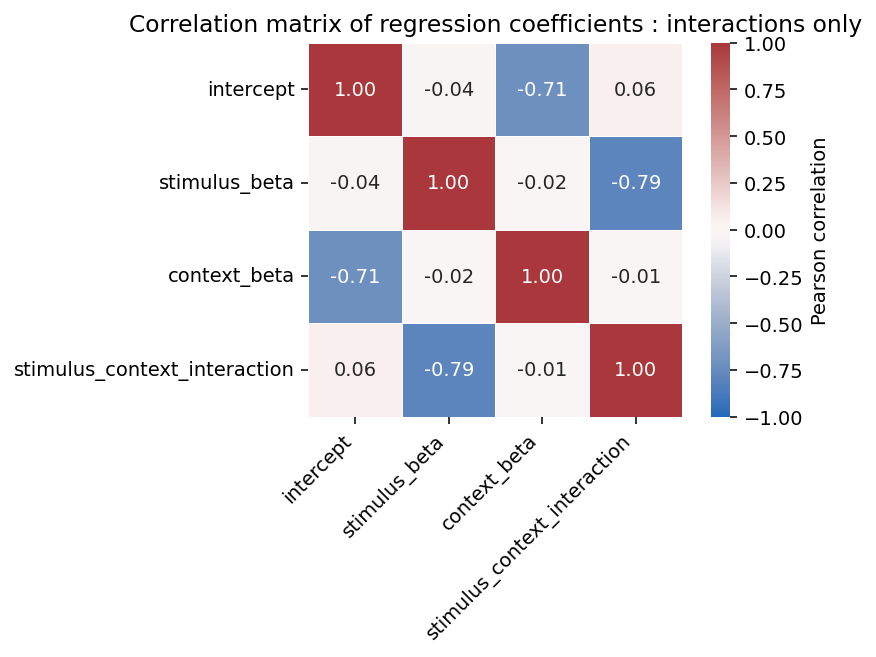

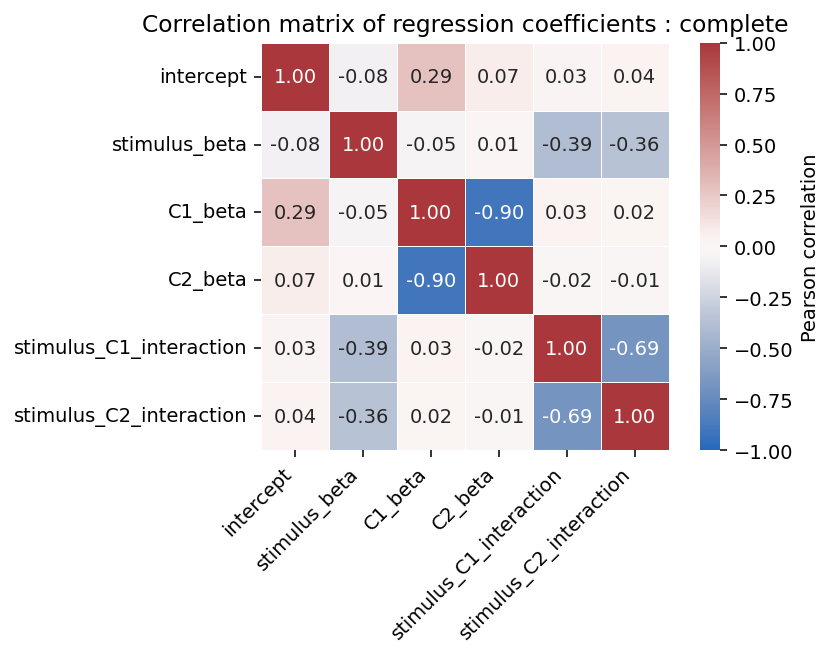

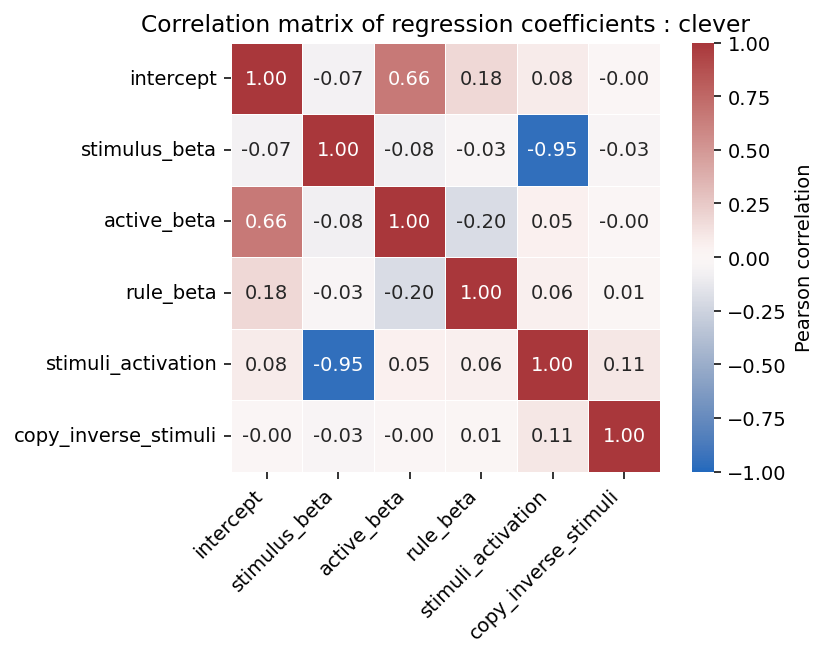

,intercept,stimulus_beta,active_beta,rule_beta,stimuli_activation,copy_inverse_stimuli
intercept,1.000000,-0.070099,0.656905,0.176427,0.079263,-0.003084
stimulus_beta,-0.070099,1.000000,-0.082746,-0.032596,-0.954585,-0.032652
active_beta,0.656905,-0.082746,1.000000,-0.202585,0.051787,-0.004396
rule_beta,0.176427,-0.032596,-0.202585,1.000000,0.058080,0.008758
stimuli_activation,0.079263,-0.954585,0.051787,0.058080,1.000000,0.105748
copy_inverse_stimuli,-0.003084,-0.032652,-0.004396,0.008758,0.105748,1.000000


In [ ]:
correlation_plot_regression_coefficients(regression_df_basic, "basic")
correlation_plot_regression_coefficients(regression_df_interaction, "interactions only")
correlation_plot_regression_coefficients(regression_df_complete, "complete")
correlation_plot_regression_coefficients(regression_df_clever, "clever")

# Sekcja rozpierducha, nie wiem o co cho


In [ ]:
task = ContextGoNoGoTask(seq_len=model_args['low_rank'].seq_len)
inputs, targets, contexts, stimuli = task.make_balanced_batch(1,
        DEVICE,
    )

with T.no_grad():
    outputs, states = model(inputs, return_states=True)

In [ ]:
h0 = model.h0.detach().cpu()


def pca_project_with_h0_adj(states, h0, n_components=2):
    """
    states: [batch, time, hidden]
    h0:     [1, hidden]

    PCA is fit on both h0 and all trajectory states.

    Returns
    -------
    Z_states:
        Projected trajectories, shape [batch, time, n_components].

    Z_h0:
        Projected initial state, shape [n_components].

    pc_vectors:
        Coordinates/loadings of the PCA vectors in the original neuron space.
        Shape [hidden, n_components].
        Each row corresponds to one neuron.
        Columns correspond to PC1, PC2, ...

    pca_info:
        Additional PCA information:
        - mean
        - singular_values
        - explained_variance_ratio
        - vt
    """
    # Make sure everything is on CPU and NumPy.
    if isinstance(states, T.Tensor):
        states_np = states.detach().cpu().numpy()
    else:
        states_np = np.asarray(states)

    if isinstance(h0, T.Tensor):
        h0_np = h0.detach().cpu().numpy()
    else:
        h0_np = np.asarray(h0)

    if h0_np.ndim == 1:
        h0_np = h0_np[None, :]

    batch_size, seq_len, hidden_size = states_np.shape

    X_states = states_np.reshape(-1, hidden_size)
    X_h0 = h0_np

    # Fit PCA on h0 + all trajectory states.
    X_all = np.concatenate([X_h0, X_states], axis=0)
    X_mean = X_all.mean(axis=0, keepdims=True)
    X_centered = X_all - X_mean

    _, singular_values, vt = np.linalg.svd(X_centered, full_matrices=False)

    # PCA axes in original neuron/state space.
    # pcs[:, 0] = PC1 loading per neuron
    # pcs[:, 1] = PC2 loading per neuron
    pcs = vt[:n_components].T  # [hidden, n_components]

    # Project activity points into PCA space.
    Z_all = X_centered @ pcs
    Z_h0 = Z_all[0]
    Z_states = Z_all[1:].reshape(batch_size, seq_len, n_components)

    # Variance explained by each PC.
    explained_variance = singular_values**2
    explained_variance_ratio = (
        explained_variance[:n_components] / explained_variance.sum()
    )

    pc_vectors = pcs

    pca_info = {
        "mean": X_mean.squeeze(0),
        "singular_values": singular_values,
        "explained_variance_ratio": explained_variance_ratio,
        "vt": vt,
    }

    return Z_states, Z_h0, pc_vectors, pca_info

In [ ]:
_, _, pc_vectors, _ = pca_project_with_h0_adj(states, h0, n_components=6)
print(pc_vectors.shape)

(256, 6)


In [ ]:
name = "low_rank"
h0_pca = get_initial_state_for_pca(models[name], name)
Z_states, Z_h0, pc_vectors, pca_info = pca_project_with_h0_adj(results[name]["states"], h0_pca, n_components=6)

In [ ]:
pc_dict = {}

for k in range(6):
    pc_name = f"PC{k + 1}"

    pc_dict[pc_name] = {
        # Trajectory coordinates on this PC.
        # Shape: [batch, time]
        "states": Z_states[:, :, k],

        # Initial state coordinate on this PC.
        # Scalar.
        "h0": Z_h0[k],

        # PC vector/loadings in neuron space.
        # Shape: [hidden]
        "vector": pc_vectors[:, k],

        # Explained variance ratio for this PC.
        "explained_variance_ratio": pca_info["explained_variance_ratio"][k],

        # Same PC vector, but directly from vt.
        # Shape: [hidden]
        "vt_vector": pca_info["vt"][k],
    }


In [ ]:
state_dict = model.state_dict()

W_in = state_dict["W_in"].detach().cpu()
W_out = state_dict["W_out"].detach().cpu()

parameter_dict = {

    "stimulus": W_in[:, 0:1],
    "cond_0": W_in[:, 1:2],
    "cond_1": W_in[:, 2:3],
    "cond_2": W_in[:, 3:4],
    "go_cue": W_in[:, 4:5],
    "output": W_out.T,
    "recurrent_injection": state_dict["U"],
    "recurrent_selection": state_dict["V"],
    "cond_1_minus_cond_2": W_in[:, 2:3] - W_in[:, 3:4],
    "active_context_minus_cond_0": ((W_in[:, 2:3] + W_in[:, 3:4]) / 2) - W_in[:, 1:2]
}

print(parameter_dict['cond_1_minus_cond_2'].shape)

torch.Size([256, 1])


In [ ]:
def giver_pca_vectors(states, n_components=2):
  h0 = model.h0.detach().cpu()
  _, _, pc_vectors, _ = pca_project_with_h0_adj(states, h0, n_components)
  pc_dict = {}
  for k in range(n_components):
    pc_name = f"PC{k + 1}"
    pc_dict[pc_name] = pc_vectors[:,[k]]
  return pc_dict

pc_dict = giver_pca_vectors(states, 6)
for name, elements in pc_dict.items():
  print(f"{name:9s} | {elements.shape}")

PC1       | (256, 1)
PC2       | (256, 1)
PC3       | (256, 1)
PC4       | (256, 1)
PC5       | (256, 1)
PC6       | (256, 1)


In [ ]:
def compute_pc_overlap_matrix(parameter_dict, pc_dict):
    rows = []

    def prep(x):
        if isinstance(x, np.ndarray):
            x = T.tensor(x, dtype=T.float32)
        else:
            x = x.detach().cpu().float()

        if x.ndim == 1:
            x = x.reshape(-1, 1)

        return x

    N = prep(next(iter(pc_dict.values()))).shape[0]

    for param_name, param in parameter_dict.items():
        param = prep(param)

        if param.shape[0] != N and param.shape[1] == N:
            param = param.T

        if param.shape[0] != N:
            continue

        for pc_name, pc in pc_dict.items():
            pc = prep(pc)

            overlap = (param.T @ pc) / N

            rows.append({
                "parameter": param_name,
                "PC": pc_name,
                "overlap": overlap.squeeze().item(),
            })

    overlap_df = pd.DataFrame(rows)

    overlap_matrix = overlap_df.pivot(
        index="parameter",
        columns="PC",
        values="overlap",
    )

    return overlap_df, overlap_matrix

PC,PC1,PC2,PC3,PC4,PC5,PC6
parameter,,,,,,
active_context_minus_cond_0,-0.002951,0.002406,0.012878,0.002465,-0.000051,-0.000062
cond_0,0.002875,-0.000199,-0.000407,-0.005213,-0.000061,-0.000755
cond_1,0.019220,0.001705,0.013171,-0.002608,-0.000141,-0.000811
cond_1_minus_cond_2,0.038592,-0.001003,0.001399,0.000280,-0.000057,0.000012
cond_2,-0.019372,0.002708,0.011772,-0.002888,-0.000084,-0.000823
go_cue,-0.002796,0.004144,0.030092,-0.007491,0.000220,0.003772
output,0.000020,-0.000071,0.000180,0.000284,0.006522,0.002924
recurrent_injection,-0.003067,-0.047050,0.005516,-0.000156,-0.005886,0.000289
recurrent_selection,-0.002979,-0.049342,0.005113,-0.000207,-0.000364,0.000400


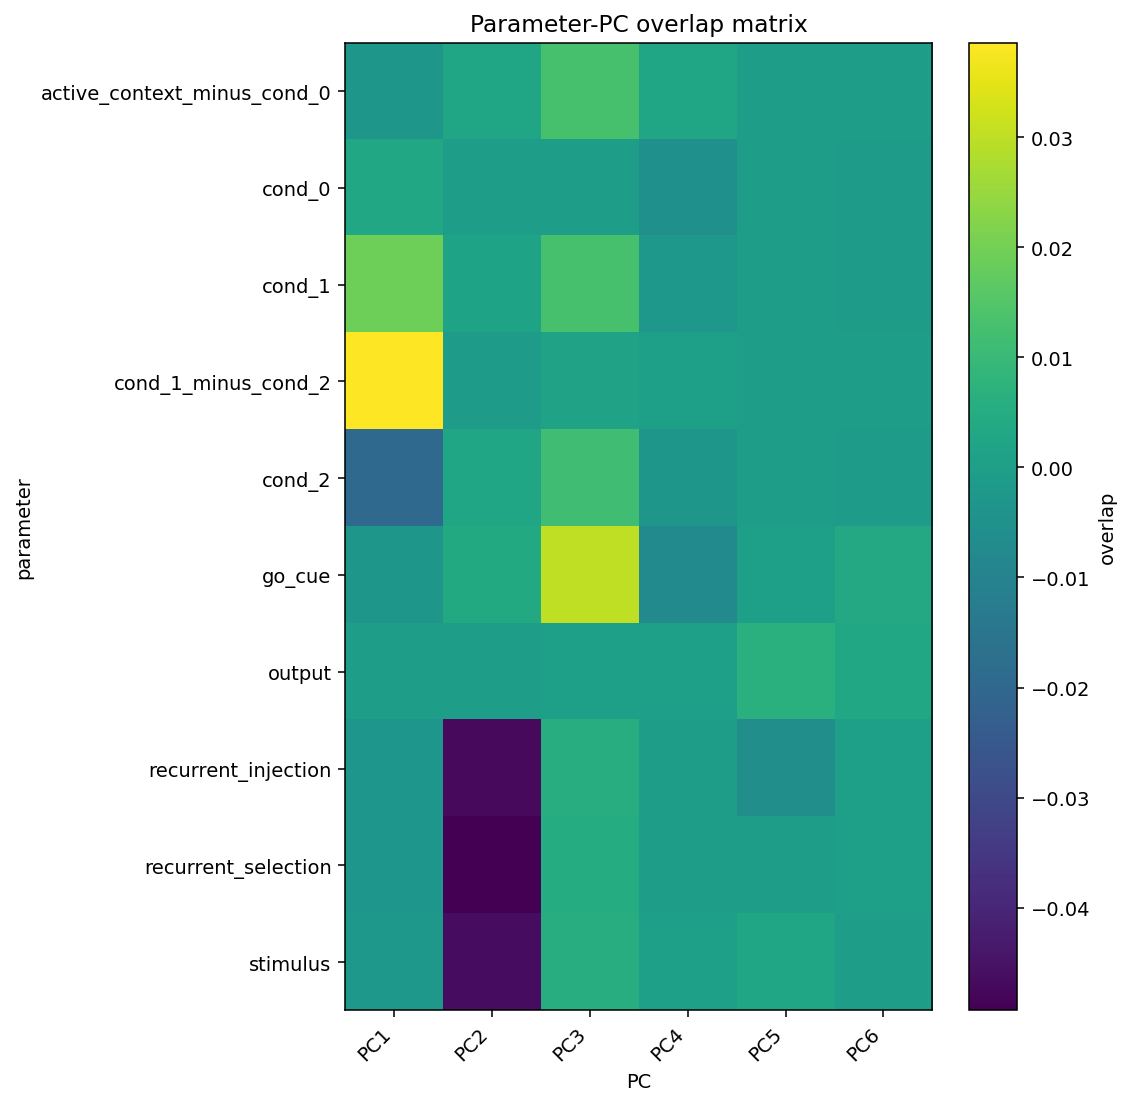

In [ ]:
overlap_df, overlap_matrix = compute_pc_overlap_matrix(parameter_dict, pc_dict)

display(overlap_matrix)

plt.figure(figsize=(8, 8), dpi=140)
plt.imshow(overlap_matrix, aspect="auto")
plt.colorbar(label="overlap")

plt.xticks(
    ticks=np.arange(overlap_matrix.shape[1]),
    labels=overlap_matrix.columns,
    rotation=45,
    ha="right",
)

plt.yticks(
    ticks=np.arange(overlap_matrix.shape[0]),
    labels=overlap_matrix.index,
)

plt.xlabel("PC")
plt.ylabel("parameter")
plt.title("Parameter-PC overlap matrix")
plt.tight_layout()
plt.show()

In [ ]:
def compute_dict_pc_overlaps(vectors, pc_dict):
    rows = []

    def prep(x):
        if isinstance(x, np.ndarray):
            x = T.tensor(x, dtype=T.float32)
        else:
            x = x.detach().cpu().float()

        if x.ndim == 1:
            x = x.reshape(-1, 1)

        return x

    # hidden size from PC vectors
    N = prep(next(iter(pc_dict.values()))).shape[0]

    for vec_name, vec in vectors.items():
        vec = prep(vec)

        # handle [1, hidden] -> [hidden, 1], e.g. W_out or h0
        if vec.shape[0] != N and vec.shape[1] == N:
            vec = vec.T

        # skip objects that do not live in hidden space
        if vec.shape[0] != N:
            continue

        for pc_name, pc in pc_dict.items():
            pc = prep(pc)

            overlap = (vec.T @ pc) / N

            for j in range(overlap.shape[0]):
                rows.append({
                    "vector": vec_name if overlap.shape[0] == 1 else f"{vec_name}_{j}",
                    "PC": pc_name,
                    "overlap": overlap[j, 0].item(),
                })

    overlap_df = pd.DataFrame(rows)

    overlap_matrix = overlap_df.pivot(
        index="vector",
        columns="PC",
        values="overlap",
    )

    return overlap_df, overlap_matrix

PC,PC1,PC2,PC3,PC4,PC5,PC6
vector,,,,,,
active_context,-0.002951,0.002406,0.012878,0.002465,-0.000051,-0.000062
copy_invert,0.038592,-0.001003,0.001399,0.000280,-0.000057,0.000012
go_cue,-0.002796,0.004144,0.030092,-0.007491,0.000220,0.003772
output,0.000020,-0.000071,0.000180,0.000284,0.006522,0.002924
recurrent_injection,-0.003067,-0.047050,0.005516,-0.000156,-0.005886,0.000289
recurrent_selection,-0.002979,-0.049342,0.005113,-0.000207,-0.000364,0.000400
stimulus,-0.002321,-0.046459,0.005548,0.000159,0.002580,-0.000155


PC,PC1,PC2,PC3,PC4,PC5,PC6
parameter,,,,,,
active_context,-0.002951,0.002406,0.012878,0.002465,-0.000051,-0.000062
copy_invert,0.038592,-0.001003,0.001399,0.000280,-0.000057,0.000012
go_cue,-0.002796,0.004144,0.030092,-0.007491,0.000220,0.003772
output,0.000020,-0.000071,0.000180,0.000284,0.006522,0.002924
recurrent_injection,-0.003067,-0.047050,0.005516,-0.000156,-0.005886,0.000289
recurrent_selection,-0.002979,-0.049342,0.005113,-0.000207,-0.000364,0.000400
stimulus,-0.002321,-0.046459,0.005548,0.000159,0.002580,-0.000155


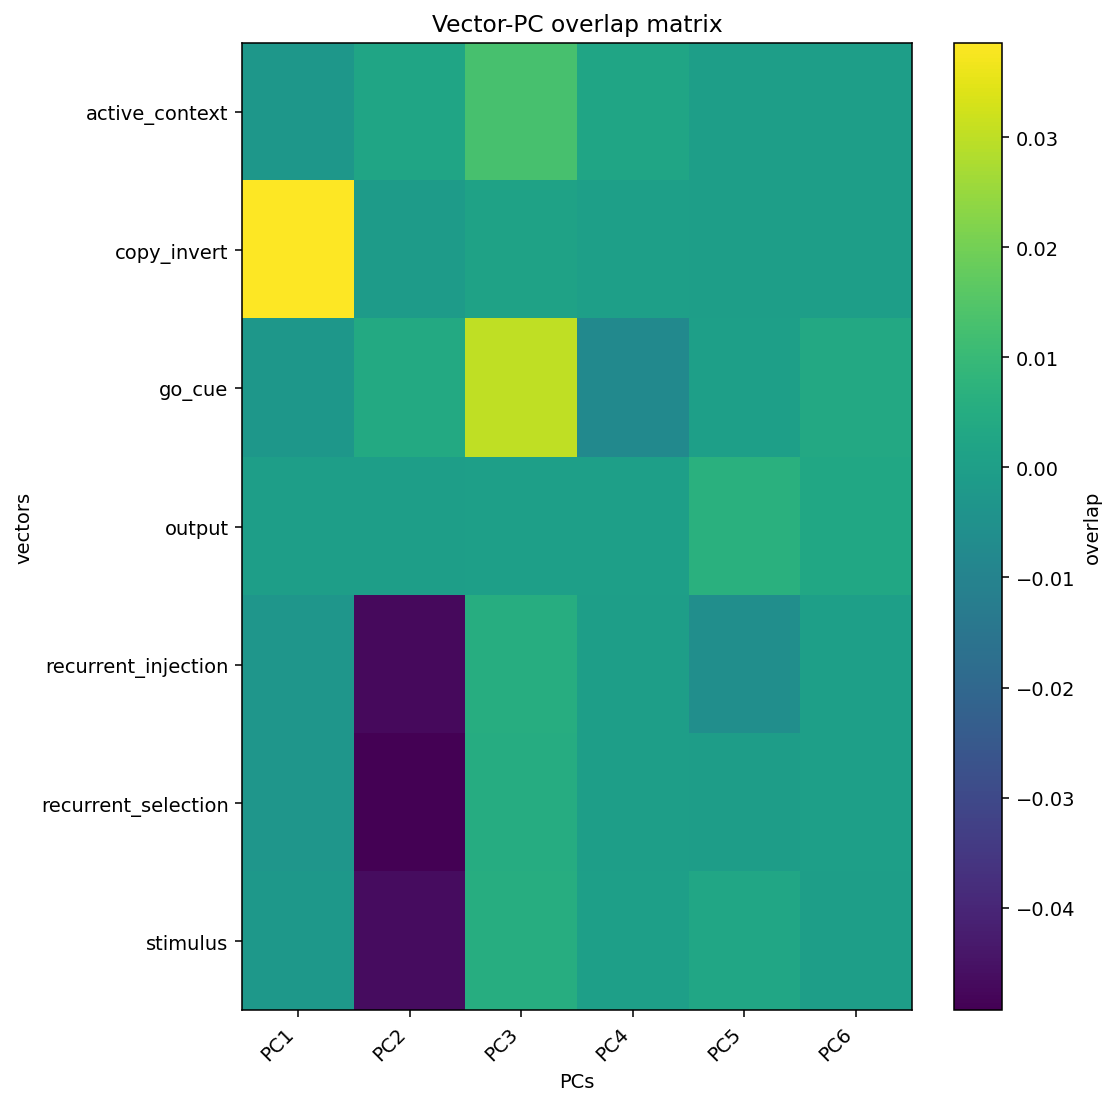

In [ ]:
overlap_df, overlap_matrix = compute_dict_pc_overlaps(
    vectors=vectors,
    pc_dict=pc_dict,
)

display(overlap_matrix)

overlap_df, overlap_matrix = compute_pc_overlap_matrix(vectors, pc_dict)

display(overlap_matrix)

overlap_df, overlap_matrix = compute_dict_pc_overlaps(
    vectors=vectors,
    pc_dict=pc_dict,
)

plt.figure(figsize=(8, 8), dpi=140)
plt.imshow(overlap_matrix.values, aspect="auto")
plt.colorbar(label="overlap")

plt.xticks(
    ticks=np.arange(overlap_matrix.shape[1]),
    labels=overlap_matrix.columns,
    rotation=45,
    ha="right",
)

plt.yticks(
    ticks=np.arange(overlap_matrix.shape[0]),
    labels=overlap_matrix.index,
)

plt.xlabel("PCs")
plt.ylabel("vectors")
plt.title("Vector-PC overlap matrix")
plt.tight_layout()
plt.show()